Import statements and Reading data into Dataframes

In [1]:
#Import statements
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pandas as pd
from scipy.spatial import cKDTree
from astropy.coordinates import SkyCoord
import astropy.units as u

import scipy.integrate as integrate
import scipy.special as special

from astropy.cosmology import Planck15 as cosmo
from astropy.cosmology import FlatLambdaCDM

import random
import math
from itertools import combinations
import matplotlib.patches as patches

In [3]:
#reads data from "XUCS_catalog_all.txt" into the dataframe data_XUCS
#define names of columns in data_XUCS
XUCS_columns = ['Id', 'RAdeg', 'DEdeg', 'z', 'logM500caustic', 'errlogM500caustic', 
                'N', 'logM500veldisp', 'errlogM500veldisp', 'n', 'Telescope', 'texp', 
                'logLX', 'errlogLX', 'logLXce', 'errlogLXce']

#Load data from csv. contains only points that are in Zarattini paper
data_XUCS = pd.read_csv("XUCS_catalog_all.txt",
                       sep='\s+',
                       skiprows=1,
                       names=XUCS_columns,
                       dtype={'Id': str, 'RAdeg': float, 'DEdeg': float, 'z': float,
                              'logM500caustic': float, 'errlogM500caustic': float,
                              'N': float, 'logM500veldisp': float, 'errlogM500veldisp': float,
                              'n': float, 'Telescope': str, 'texp': float,
                              'logLX': float, 'errlogLX': float, 'logLXce': float, 'errlogLXce': float})

#print length of the column 'Id' in data_XUCS
print(len(data_XUCS['Id']))

29


In [3]:
#read data from 'filament_catalog.txt' into data_filaments
data_filaments = pd.read_csv('filament_catalog.txt', delim_whitespace = True, names = ['Type','RAdeg', 'DEdeg', 'zLow'], skiprows = 13)

In [4]:
#read data from 'Andreon2025Data.csv' (data_Dist) and add to data_XUCS
data_Dist = pd.read_csv('Andreon2025Data.csv')
#sort data by Id
data_Dist.sort_values(by = 'Id',axis = 0)

data_XUCS = pd.merge(data_XUCS, data_Dist[['Id', 'min_distance_to_filament_Haversin (Mpc)']], on='Id', how='left')

#renames one column of data_XUCS
data_XUCS.rename(columns = {'min_distance_to_filament_Haversin (Mpc)':'Haversin_Dist_Zar (Mpc)'}, inplace = True)

Adding Euclidean and Haversin distances (degrees and Mpc) to data_XUCS

In [5]:
#changing RA and Dec points into euclidian and haversin distances to filaments using trees
#make a loop so it does this for all zLow values
for i in range(20,100,5):
    x = int(i/5-4)
    zLow = i/1000
    #write out zLow and zHigh
    zHigh = zLow + 0.005
    
    #print(zLow)

    #Find filaments from filament catalog that are equal to zLow
    filaments_z = data_filaments[(data_filaments['Type'] == 'Filament') & (data_filaments['zLow'] == zLow)]

    #find clusters from the XUCS paper that are within 120<= RA <= 240, 0<= DE <= 60 and between zLow and zHigh
    XUCS_z = data_XUCS[(data_XUCS['RAdeg'] >= 120) &
                       (data_XUCS['RAdeg'] <= 240) &
                       (data_XUCS['DEdeg'] >= -1) &
                        (data_XUCS['DEdeg'] <= 61) &
                       (data_XUCS['z'] >= zLow) &
                       (data_XUCS['z'] < zHigh)
                      ]

    #use Kdtrees to find minimum distances between points in XUCS_z and filaments_z and add them to a column in data_XUCS
    ra_fil = filaments_z['RAdeg'].values
    dec_fil = filaments_z['DEdeg'].values
    ra_XUCS = XUCS_z['RAdeg'].values
    dec_XUCS = XUCS_z['DEdeg'].values
    
    coords_fil = np.vstack((ra_fil, dec_fil)).T
    tree = cKDTree(coords_fil)

    coords_XUCS = np.vstack((ra_XUCS, dec_XUCS)).T
    distances_Euclid, indices = tree.query(coords_XUCS)

    #print("Distances (in degrees) from each XUCS point to nearest filament:")
    #print("Euclidean distances=")
    #print(distances_Euclid)
    

    # Use the index from XUCS_z to map distances back to original DataFrame
    data_XUCS.loc[XUCS_z.index, 'min_distance_to_filament_Euclid_MT (degrees)'] = distances_Euclid
    
    
    #finds haversin distances from sky coordinate objects

    # Convert to SkyCoord objects
    coords_fil = SkyCoord(ra=ra_fil * u.deg, dec=dec_fil * u.deg)
    coords_XUCS = SkyCoord(ra=ra_XUCS * u.deg, dec=dec_XUCS * u.deg)

    # Compute closest angular distance for each XUCS point to any filament point
    # 'separation' returns angles; 'min()' gives closest match
    distances_Haversin = np.min(coords_XUCS[:,None].separation(coords_fil[None, :]).deg, axis=1)

    # Print distances in degrees
    #print("Angular distances=")
    #print(distances_Haversin)
    
    # Use the index from XUCS_z to map distances back to original DataFrame
    data_XUCS.loc[XUCS_z.index, 'min_distance_to_filament_Haversin_MT (degrees)'] = distances_Haversin


In [6]:
#Adds a zLow Column to data_XUCS (useful for finding distances in Mpc)
#weird numbers cause otherwise the bins do not include the low range of their values
bins = np.arange(0.019999999999999, 0.13999999999999, 0.005)

z_values = data_XUCS['z'].values

# Use np.digitize to find bin index for each z (subtract 1 to get lower bin edge index)
bin_indices = np.digitize(z_values, bins,right = True) - 1

# Initialize all as NaN
zLow_column = np.full_like(z_values, fill_value=np.nan, dtype=np.float64)

# Mask valid z values (within bin range)
valid_mask = (bin_indices >= 0) & (bin_indices < len(bins))

# Assign corresponding lower bin edge
zLow_column[valid_mask] = bins[bin_indices[valid_mask]]

data_XUCS['zLow'] = zLow_column

data_XUCS['zLow'] = data_XUCS['zLow']*200
data_XUCS.round()
data_XUCS['zLow'] = data_XUCS['zLow']/200

In [7]:
#setup functions for finding distance in megaparsecs


def integrand(a):
    return 1.0/np.sqrt(0.3*((1+a)**3)+1-0.3)
def proper_distance(z):
    c = 299792.458 #km*s-1 
    H0 = 70
    
    integral, _ = integrate.quad(integrand,0,z)
    
    distance = (c / H0) * integral  # result in Mpc
    
    return distance

In [8]:
#actually finds distances in Mpc. adds to dataframe

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

transverse = []
for i in range(len(data_XUCS['Id'])):
    # θ in degrees
    theta_deg = data_XUCS.loc[i,'min_distance_to_filament_Haversin_MT (degrees)']
    z = data_XUCS.loc[i, 'zLow']
    z = z + 0.0025

    # Convert θ to radians
    theta_rad = np.deg2rad(theta_deg)

    # proper distance in Mpc
    prop_dist = proper_distance(z) 

    # Angular diameter distance
    D_A = prop_dist / (1 + z)

    # Transverse physical distance in Mpc
    transverse_distance = theta_rad * D_A
    
    transverse.append(transverse_distance)

data_XUCS['min_distance_to_filament_Haversin_MT (Mpc)'] = transverse

Calculate and add surface brightness and error in SB to data_XUCS

In [9]:
#function that adds surface brightness of clusters to a given dataframe
def surface_brightness(Data, Mpc_column, new_column, H0):
    # SB = Lx500ce/(pi(r500^2)) <-- technically 0.99pi(r500^2)
    #H0 = 2.26853*10**(-18)
    Om0=0.3
    G = 4.52*(10**(-48))
    #1.4756x10^37
    
    M500 = 10**Data['logM500caustic']
    Luminosity = (10)**Data['logLXce']
    zVals = Data['z']
    z=zVals
    
    hz = (np.sqrt(Om0*((1+z)**3)+(1-Om0)))
    
    ro_crit = (3*((H0*hz)**2))/(8*np.pi*G)
    
    r500_vals = ((3*M500)/(4*np.pi*500*ro_crit))**(1/3)
    
    
    hDist = Data[Mpc_column]
    
    
    SB = 0.99*Luminosity / (np.pi * r500_vals**2)  # erg/s/Mpc²
    
    # Add to DataFrame
    Data[new_column] = np.log10(SB)

H0 = 2.26853*10**(-18) #units: seconds; equal to 70 km*s^-1*mpc^-1
surface_brightness(data_XUCS,'min_distance_to_filament_Haversin_MT (Mpc)','SB_Tarnopolski',H0)
surface_brightness(data_XUCS,'Haversin_Dist_Zar (Mpc)','SB_Zarattini',H0)


In [10]:
#Function that adds error in surface brightness to given dataframe
def error_in_SB(data):
    data['SB err'] = np.sqrt((data['errlogLXce'])**2 + (4/9)*(data['errlogM500caustic'])**2)

error_in_SB(data_XUCS)

In [11]:
data_XUCS

,Id,RAdeg,DEdeg,z,logM500caustic,errlogM500caustic,N,logM500veldisp,errlogM500veldisp,n,...,logLXce,errlogLXce,Haversin_Dist_Zar (Mpc),min_distance_to_filament_Euclid_MT (degrees),min_distance_to_filament_Haversin_MT (degrees),zLow,min_distance_to_filament_Haversin_MT (Mpc),SB_Tarnopolski,SB_Zarattini,SB err
0,CL1001,208.256,5.134,0.079,14.30,0.11,171.0,14.57,0.09,124.0,...,43.79,0.01,0.98,0.228450,0.228076,0.075,1.204498,43.412787,43.412787,0.074012
1,CL1009,198.057,-0.974,0.085,14.00,0.26,236.0,14.28,0.12,56.0,...,43.24,0.02,1.56,1.974205,1.974190,0.085,11.635471,43.064481,43.064481,0.174483
2,CL1011,227.107,-0.266,0.091,14.23,0.17,48.0,14.46,0.14,42.0,...,42.77,0.07,6.14,0.704904,0.704903,0.090,4.366675,42.442852,42.442852,0.133208
3,CL1014,175.299,5.735,0.098,14.40,0.09,120.0,14.40,0.16,51.0,...,43.31,0.04,1.03,0.359768,0.359767,0.095,2.335642,42.871517,42.871517,0.072111
4,CL1015,182.570,5.386,0.077,13.85,0.19,79.0,14.14,0.15,37.0,...,43.55,0.01,2.72,1.758303,1.757348,0.075,9.280785,43.472224,43.472224,0.127061
5,CL1018,214.398,2.053,0.054,13.68,0.24,123.0,14.27,0.10,79.0,...,42.73,0.05,0.40,0.376579,0.376495,0.050,1.387013,42.759156,42.759156,0.167631
6,CL1020,176.028,5.798,0.103,13.94,0.35,29.0,14.61,0.14,43.0,...,43.61,0.03,2.22,NaN,NaN,0.100,NaN,43.479618,43.479618,0.235254
7,CL1022,199.821,-0.919,0.083,13.86,0.12,87.0,13.56,0.16,36.0,...,42.55,0.10,1.50,2.404597,2.404588,0.080,13.439924,42.467249,42.467249,0.128062
8,CL1030,206.165,2.860,0.078,14.16,0.09,86.0,14.12,0.21,41.0,...,42.54,0.09,2.06,0.091046,0.090999,0.075,0.480577,42.255838,42.255838,0.108167
9,CL1033,167.747,1.128,0.097,13.83,0.12,77.0,13.79,0.21,20.0,...,43.05,0.05,0.67,0.817263,0.817210,0.095,5.305401,42.991231,42.991231,0.094340


Plotting SB vs distances

Zarattini

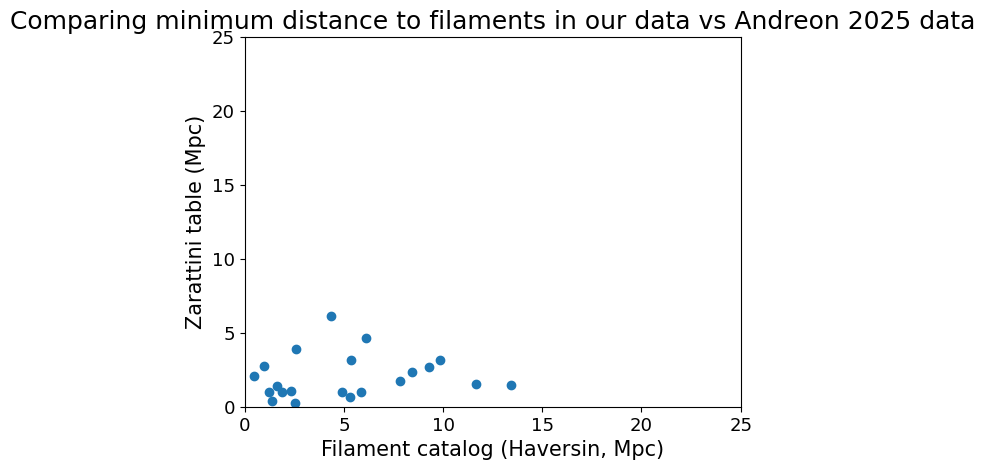

In [21]:
#Plotting distances to Tarnopolski catalog against distances in Zarattini table
plt.figure()
xPts = data_XUCS['min_distance_to_filament_Haversin_MT (Mpc)']
yPts = data_XUCS['Haversin_Dist_Zar (Mpc)']
plt.scatter(xPts,yPts)
plt.title('Comparing minimum distance to filaments in our data vs Andreon 2025 data')
plt.xlabel('Filament catalog (Haversin, Mpc)')
plt.ylabel('Zarattini table (Mpc)')
plt.xlim(0,25)
plt.ylim(0,25)
plt.show()

In [22]:
# function that plots error bars
def plot_errors(SB,lowX,highX):
    count = np.count_nonzero(~np.isnan(SB))
    Avg = np.nanmean(SB)
    Std = np.std(SB, ddof=1)
    Err = Std/np.sqrt(count)
    colors = ['#4a2377','#8cc5e3','#f55f74','#0d7d87']

    plt.hlines(Avg,lowX,highX,colors = colors[color_count],zorder = 1)
    #plt.hlines(Avg+Err,lowX,highX,colors = colors[color_count],zorder = 1)
    #plt.hlines(Avg-Err,lowX,highX,colors = colors[color_count],zorder = 1)

    x1,x2 = lowX,highX
    y1,y2 = Avg-Err,Avg+Err
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,color = colors[color_count],alpha=0.25)
    plt.gca().add_patch(rect)
    
    print(f'For {colors[color_count]}, Average: {Avg}, Lower error bound: {Avg-Err}, Upper error bound: {Avg+Err}')

In [23]:
# function that plots error bars, used for plotting multiple points and errors in the same plot
def plot_errors_specific(SB,Xval):
    count = np.count_nonzero(~np.isnan(SB))
    Avg = np.nanmean(SB)
    Std = np.std(SB, ddof=1)
    Err = Std/np.sqrt(count)
    colors = ['red','orange','green','purple']
    labels = ['Tarnopolski','Zarattini','Carron Duque (24)','Carron Duque (17)']

    plt.plot(Xval,Avg)
    plt.errorbar(Xval,Avg,yerr=Err,fmt='o-',capsize=5,color=colors[color_count],linewidth=1)

    

For #4a2377, Average: 2.9083333333333328, Lower error bound: 2.072397065161862, Upper error bound: 3.7442696015048034
For #8cc5e3, Average: 1.7893333333333332, Lower error bound: 1.4665161704765226, Upper error bound: 2.112150496190144
For #f55f74, Average: 1.33125, Lower error bound: 1.0215759922572956, Upper error bound: 1.6409240077427045


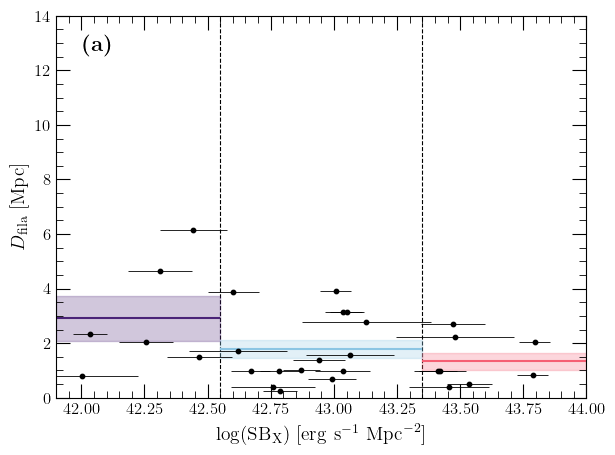

In [24]:

#plotting a reproduction of Zarattini paper, includes individual horizontal and total mean error bars
plt.figure()
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "figure.figsize": (3.5, 3.2), # Standard A&A single-column size
    "axes.labelsize": 10,         # A&A standard size
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})


lowSB = data_XUCS.loc[(data_XUCS['SB_Tarnopolski'] <= 42.55), 'Haversin_Dist_Zar (Mpc)']
medSB = data_XUCS.loc[(42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'Haversin_Dist_Zar (Mpc)']
highSB = data_XUCS.loc[43.35 < data_XUCS['SB_Tarnopolski'], 'Haversin_Dist_Zar (Mpc)']

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

#plt.title('Surface Brightness vs Distance to Filaments, reproduction of Zarattini paper')
plt.scatter(data_XUCS['SB_Tarnopolski'],data_XUCS['Haversin_Dist_Zar (Mpc)'], c = 'black', s= 10,zorder = 2)
plt.errorbar(data_XUCS['SB_Tarnopolski'],data_XUCS['Haversin_Dist_Zar (Mpc)'],xerr= data_XUCS['SB err'], linestyle='None', capsize=0,c = 'black',linewidth=0.6,zorder = 2)
#plt.ylabel('Distance to filament (Mpc)')
#plt.xlabel(r'$\log_{10}(SB_x) (\mathrm{erg\ s^{-1}\ Mpc^{-2}})$')
plt.text(
    0.05, 0.95,
    r'\bf(a)',
    transform=plt.gca().transAxes,
    fontsize=16,
    va='top',
    ha='left',
    zorder = 5
)

# 1. Enable minor ticks
plt.minorticks_on()

# 2. Configure major and minor ticks
# 'both' applies to x and y; 'direction="in"' flips them inside
# 'top=True' and 'right=True' creates the "box" effect
plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=12, zorder = 0)

# 3. Make major ticks longer/thicker for better visibility
plt.tick_params(which='major', length=10, width=0.8, zorder = 0)
plt.tick_params(which='minor', length=5, width=0.6, zorder = 0)

plt.xlabel(r'$\log(\mathrm{SB}_{\mathrm{X}}) \ [\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{Mpc}^{-2}]$', fontsize=14)
plt.ylabel(r'$D_{\mathrm{fila}} \ [\mathrm{Mpc}]$', fontsize=14)

plt.axvline(x=42.55,c='black',linestyle='dashed',linewidth = 0.8, zorder = 0)
plt.axvline(x=43.35,c='black',linestyle='dashed',linewidth = 0.8, zorder = 0)
plt.xlim(41.9,44)
plt.ylim(0,14)
plt.tight_layout()
plt.savefig('SBvsDist_Zarr_29.pdf',format='pdf',bbox_inches='tight', dpi=300)

For #4a2377, Average: 2.9083333333333328, Lower error bound: 2.072397065161862, Upper error bound: 3.7442696015048034
For #8cc5e3, Average: 1.7893333333333332, Lower error bound: 1.4665161704765226, Upper error bound: 2.112150496190144
For #f55f74, Average: 1.33125, Lower error bound: 1.0215759922572956, Upper error bound: 1.6409240077427045


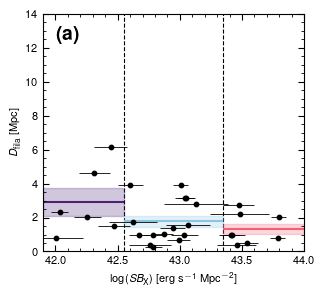

In [77]:
# plotting a reproduction of Zarattini paper, includes individual horizontal and total mean error bars
plt.figure()

# --- 1. SET GLOBAL A&A STYLE ---
plt.rcParams.update({
    "text.usetex": True,           # Enables full LaTeX rendering
    "font.family": "sans-serif",        # Matches the A&A serif style
    "font.sans-serif": ["Helvetica", "Arial"],
    "text.latex.preamble": r"\usepackage{helvet} \usepackage{sfmath}",
    "axes.labelsize": 8,       # For theta'(f) and f
    "xtick.labelsize": 8,      # For 0, pi, 2pi...
    "ytick.labelsize": 8,      # For 0.9, 1.0, 1.1...
    "legend.fontsize": 8,
    
    # Figure size for a single-column journal (3.5 inches wide)
    "figure.figsize": (3.5, 2.8)
})


# --- 2. DATA SEGMENTATION ---
lowSB = data_XUCS.loc[(data_XUCS['SB_Tarnopolski'] <= 42.55), 'Haversin_Dist_Zar (Mpc)']
medSB = data_XUCS.loc[(42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'Haversin_Dist_Zar (Mpc)']
highSB = data_XUCS.loc[43.35 < data_XUCS['SB_Tarnopolski'], 'Haversin_Dist_Zar (Mpc)']

# --- 3. PLOT ERROR REGIONS (Z-ORDER 1) ---
color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

# --- 4. DATA POINTS & ERROR BARS (Z-ORDER 2 & 3) ---
# Individual error bars (behind the points)
plt.errorbar(data_XUCS['SB_Tarnopolski'], data_XUCS['Haversin_Dist_Zar (Mpc)'], 
             xerr=data_XUCS['SB err'], linestyle='None', capsize=0, 
             c='black', linewidth=0.6, zorder=2)

# Individual scatter points (on top of bars)
plt.scatter(data_XUCS['SB_Tarnopolski'], data_XUCS['Haversin_Dist_Zar (Mpc)'], 
            c='black', s=10, zorder=3)

# Subplot label (a)
plt.text(0.05, 0.95, r'\textbf{(a)}', transform=plt.gca().transAxes, 
         fontsize=14, va='top', ha='left', zorder=5)

# --- 5. AXES & TICK STYLING (The "Science" Look) ---
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.tick_params(which='major', length=4, width=0.8)
plt.tick_params(which='minor', length=2, width=0.6)

# Properly formatted LaTeX labels
plt.xlabel(r'$\log(SB_{\mathrm{X}}) \ [\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{Mpc}^{-2}]$')
plt.ylabel(r'$D_{\mathrm{fila}} \ [\mathrm{Mpc}]$')

# --- 6. BOUNDARIES & LIMITS ---
plt.axvline(x=42.55, c='black', linestyle='dashed', linewidth=0.8, zorder=0)
plt.axvline(x=43.35, c='black', linestyle='dashed', linewidth=0.8, zorder=0)

plt.xlim(41.9, 44)
plt.ylim(0, 14)

plt.tight_layout()
plt.savefig('SBvsDist_Zarr_29.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

21
For #4a2377, Average: 3.3339999999999996, Lower error bound: 2.4528666389246174, Upper error bound: 4.215133361075382
For #8cc5e3, Average: 1.6385714285714286, Lower error bound: 1.3319488178074617, Upper error bound: 1.9451940393353955
For #f55f74, Average: 1.85, Lower error bound: 0.98, Upper error bound: 2.72


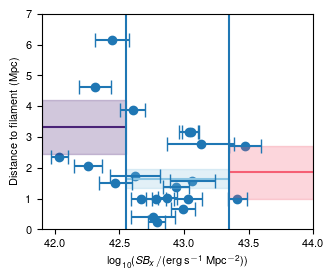

In [52]:
#plotting Zarattini paper matching the points used in finding distances to Tarnopolski catalog
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

xDat = data_XUCS.loc[mask,'SB_Tarnopolski']
print(len(xDat))
yDat = data_XUCS.loc[mask,'Haversin_Dist_Zar (Mpc)']

plt.figure()
#plt.title('Surface Brightness vs Distance to Filaments, reproduction of Zarattini paper')
plt.scatter(xDat, yDat)
plt.errorbar(xDat,yDat,xerr= data_XUCS.loc[mask,'SB err'], linestyle='None', capsize=5)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel(r'$\log_{10}(SB_x / (\mathrm{erg\ s^{-1}\ Mpc^{-2}}))$')
#add vertical lines at 42.55 and 43.35


lowSB = data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'Haversin_Dist_Zar (Mpc)']
medSB = data_XUCS.loc[mask & (42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'Haversin_Dist_Zar (Mpc)']
highSB = data_XUCS.loc[mask & (43.35 < data_XUCS['SB_Tarnopolski']), 'Haversin_Dist_Zar (Mpc)']

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
plt.ylim(0,7)
plt.savefig('SBvsDist_Zarr_21.pdf',format='pdf')

For #4a2377, Average: 3.3339999999999996, Lower error bound: 2.4528666389246174, Upper error bound: 4.215133361075382
For #8cc5e3, Average: 1.6385714285714286, Lower error bound: 1.3319488178074617, Upper error bound: 1.9451940393353955
For #f55f74, Average: 1.85, Lower error bound: 0.98, Upper error bound: 2.72


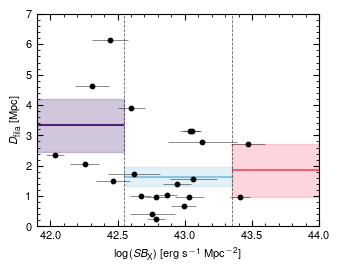

In [21]:
plt.figure()


# --- 2. MASKED DATA ---
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

xDat = data_XUCS.loc[mask, 'SB_Tarnopolski']
yDat = data_XUCS.loc[mask, 'Haversin_Dist_Zar (Mpc)']

# --- 3. SURFACE BRIGHTNESS BINS ---
lowSB  = data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55),
                       'Haversin_Dist_Zar (Mpc)']
medSB  = data_XUCS.loc[mask & (42.55 < data_XUCS['SB_Tarnopolski']) &
                       (data_XUCS['SB_Tarnopolski'] <= 43.35),
                       'Haversin_Dist_Zar (Mpc)']
highSB = data_XUCS.loc[mask & (43.35 < data_XUCS['SB_Tarnopolski']),
                       'Haversin_Dist_Zar (Mpc)']

# --- 4. ERROR REGIONS (Z-ORDER 1) ---
color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

# --- 5. INDIVIDUAL ERROR BARS (Z-ORDER 2) ---
plt.errorbar(
    xDat, yDat,
    xerr=data_XUCS.loc[mask, 'SB err'],
    linestyle='None',
    capsize=0,
    c='black',
    linewidth=0.4,
    alpha=0.8,
    zorder=2
)

# --- 6. SCATTER POINTS (Z-ORDER 3) ---
plt.scatter(
    xDat, yDat,
    c='black',
    s=10,
    zorder=3
)

# --- 7. AXES & TICKS ---
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.tick_params(which='major', length=4, width=0.8)
plt.tick_params(which='minor', length=2, width=0.6)

# --- 8. LABELS (MATCHED TO PREVIOUS FIGURE) ---
plt.xlabel(r'$\log(SB_{\mathrm{X}}) \ [\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{Mpc}^{-2}]$')
plt.ylabel(r'$D_{\mathrm{fila}} \ [\mathrm{Mpc}]$')

# --- 9. BIN BOUNDARIES ---
plt.axvline(42.55, color='black', linestyle='--', linewidth=0.6, alpha=0.6, zorder=1)
plt.axvline(43.35, color='black', linestyle='--', linewidth=0.6, alpha=0.6, zorder=1)

# --- 10. LIMITS ---
plt.xlim(41.9, 44)
plt.ylim(0, 7)

plt.tight_layout()
plt.savefig('SBvsDist_Zarr_21.pdf', bbox_inches='tight')
plt.show()

Tarnopolski

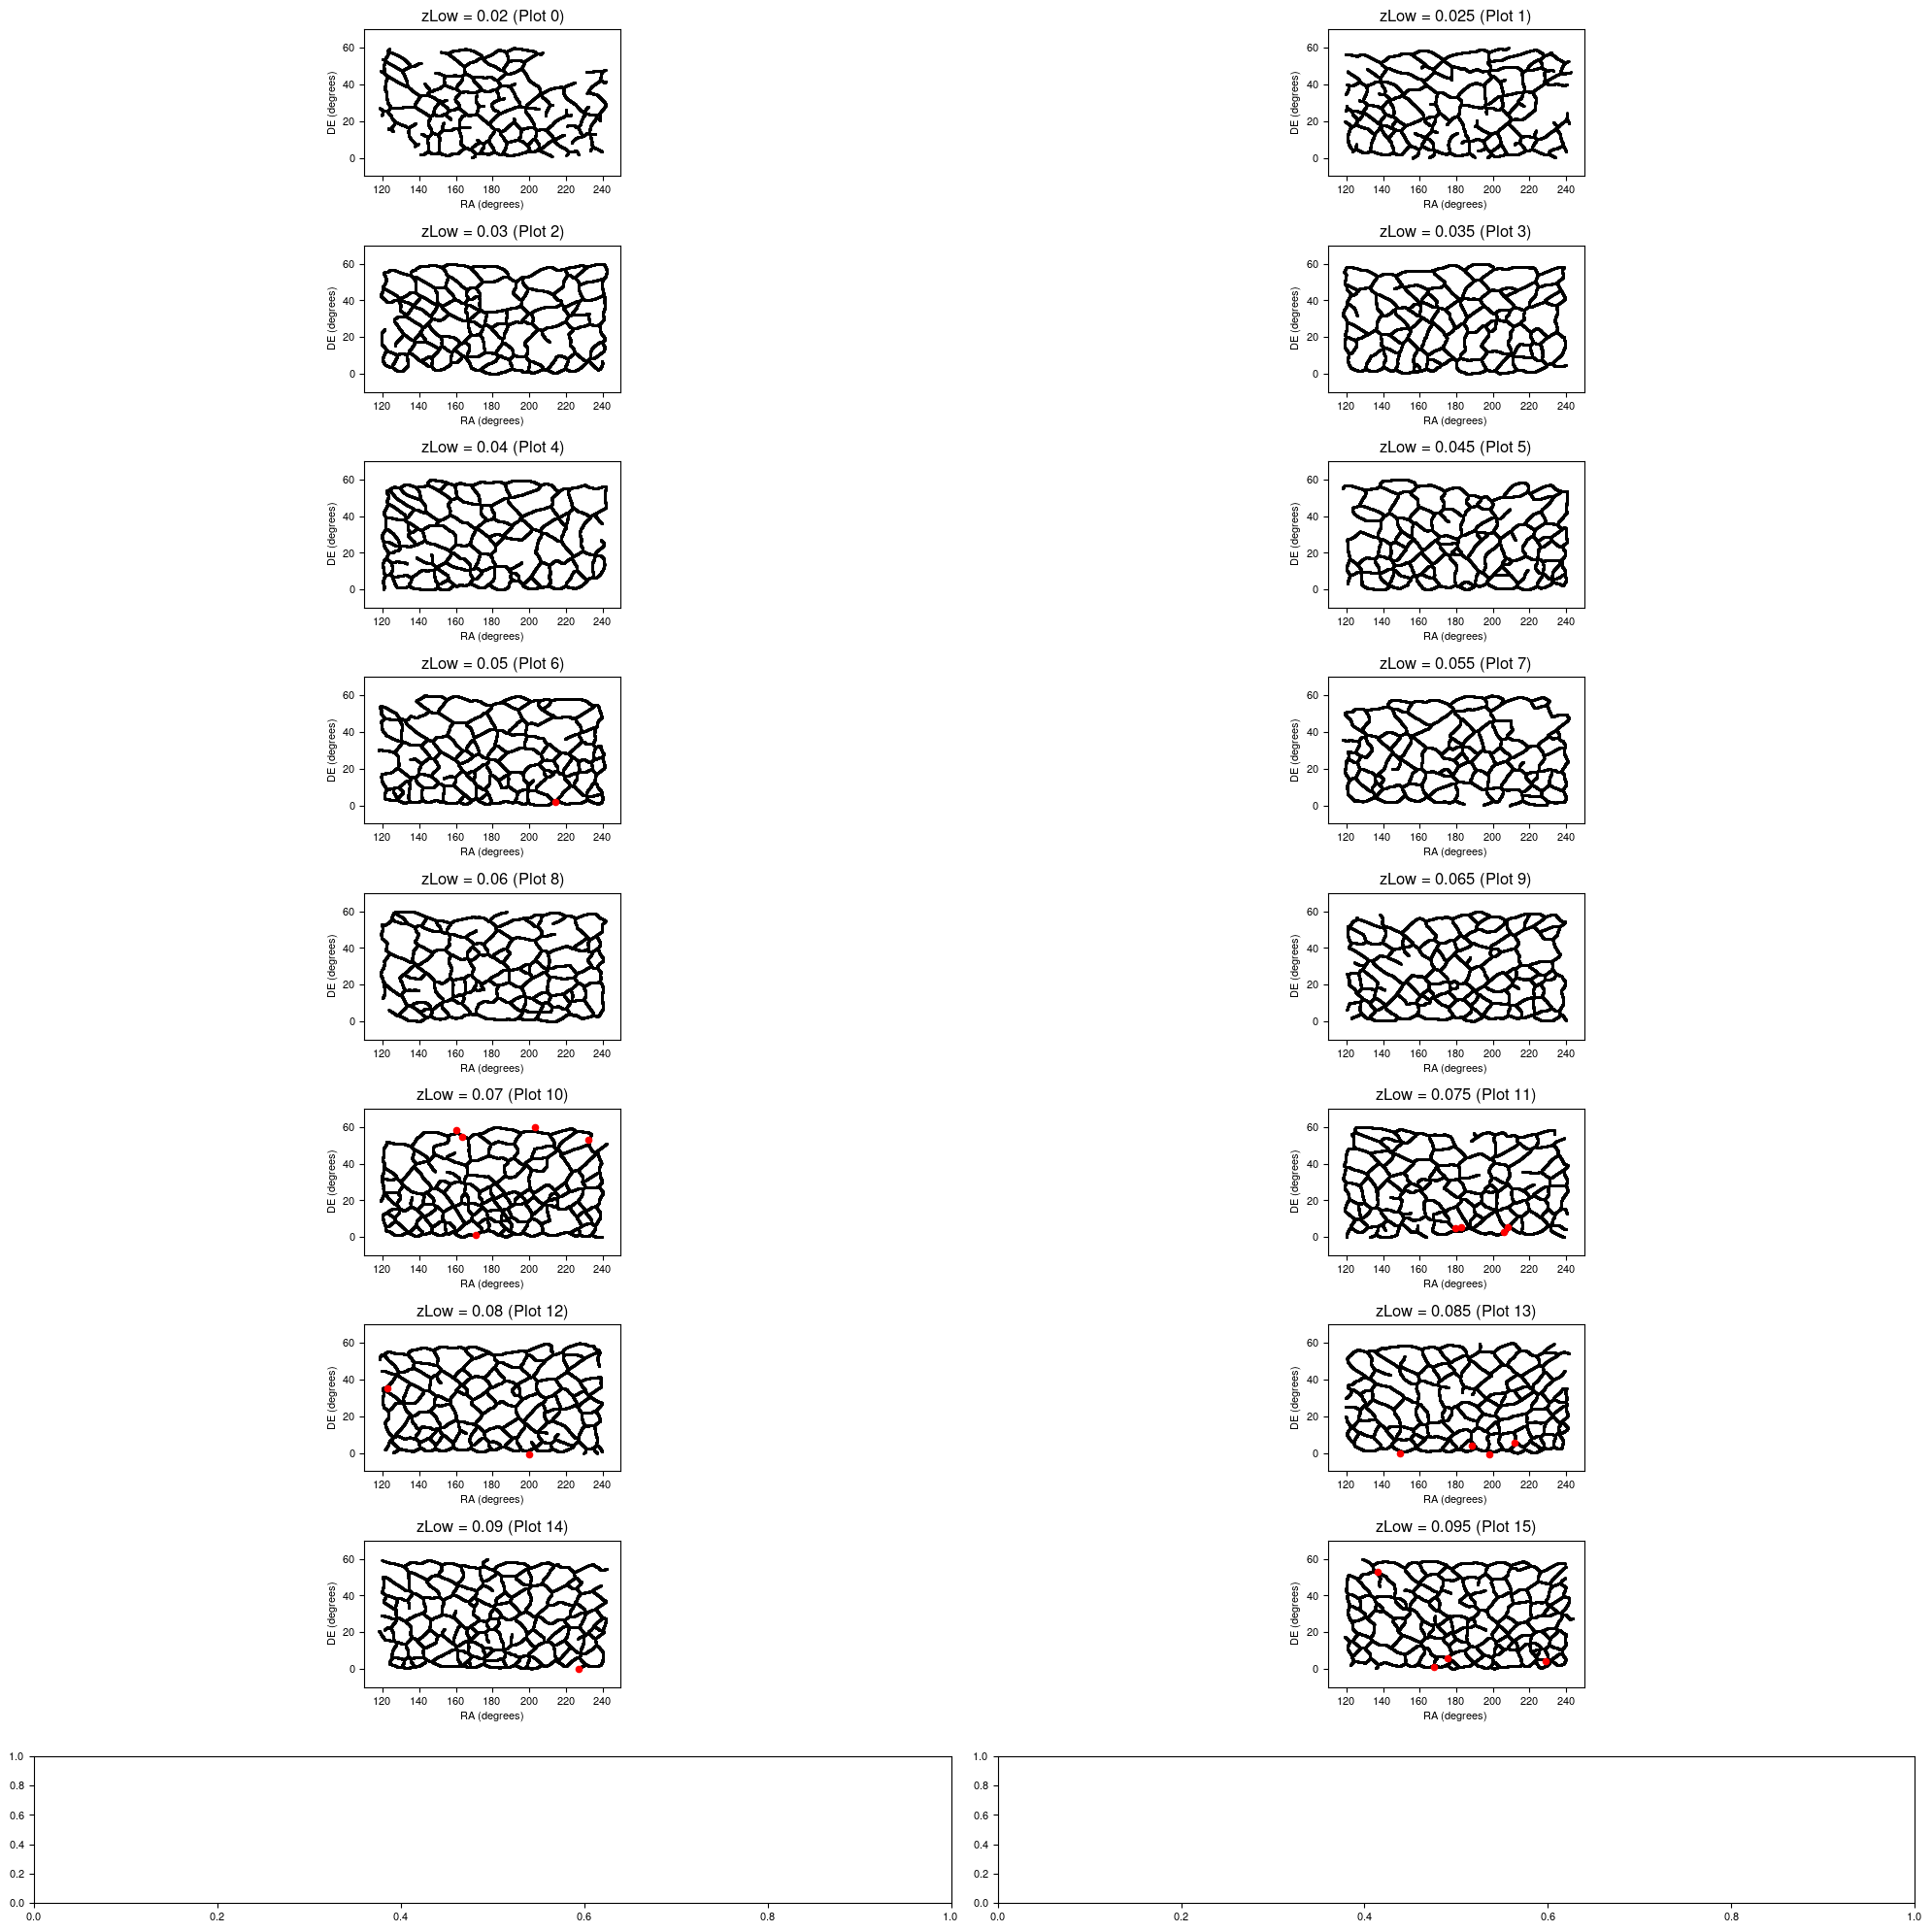

In [22]:
%%script false --no-raise-error
#Plotting graphs from Tarnopolski of each zLow layer with 21 points
fig, axs = plt.subplots(9, 2, figsize=(20, 20))  # axs is a 3x6 array of axes

ticks = [0,20,40,60]

#allows for iteration
axs = axs.flatten()


#iterates through integers 20-95 with a 5 step in order to use integer indicies and have correct titles, zLow 
#values, etc.
for i in range(20,100,5):
    x = int(i/5-4)
    z = i/1000
        
    #create scatter plot, filaments
    axs[x].scatter(data_filaments.loc[(data_filaments['zLow'] == z) & (data_filaments['Type'] == 'Filament'), "RAdeg"], data_filaments.loc[ (data_filaments['zLow'] == z) & (data_filaments['Type'] == 'Filament'), "DEdeg"], color= 'black', s = 1)
    
    #Intersections
    #axs[x].scatter(data_filaments.loc[(data_filaments['zLow'] == z) & (data_filaments['Type'] == 'Intersecton'), "RAdeg"], data_filaments.loc[ (data_filaments['zLow'] == z) & (data_filaments['Type'] == 'Intersecton'), "DEdeg"], color= 'blue', s = 1)
    
    #void centroids
    #axs[x].scatter(df4.loc[df4['zLow'] == z, "RA(deg)"], df4.loc[df4['zLow'] == z, "DE(deg)"], color= 'purple', s = 1)
    
    
    #Andreon paper
    axs[x].scatter(data_XUCS.loc[mask & (data_XUCS['z'] >= z) & (data_XUCS['z'] < (z+0.005)), "RAdeg"], data_XUCS.loc[ mask & (data_XUCS['z'] >= z) & (data_XUCS['z'] < (z+0.005)), "DEdeg"], color='red', s=20)
    
    
    axs[x].set_title(f"zLow = {z} (Plot {x})")
    axs[x].set_xlabel("RA (degrees)")
    axs[x].set_ylabel("DE (degrees)")
    axs[x].set_xlim(110, 250)  # RA from 120 to 240
    axs[x].set_ylim(-10, 70)
    axs[x].set_yticks(ticks)
    axs[x].set_yticklabels(ticks)
    axs[x].set_aspect('equal')
        
# Adjust layout
plt.tight_layout()
#plt.savefig(fname= 'MT_plots',format='pdf')
plt.show()

In [23]:
data_XUCS

,Id,RAdeg,DEdeg,z,logM500caustic,errlogM500caustic,N,logM500veldisp,errlogM500veldisp,n,...,logLXce,errlogLXce,Haversin_Dist_Zar (Mpc),min_distance_to_filament_Euclid_MT (degrees),min_distance_to_filament_Haversin_MT (degrees),zLow,min_distance_to_filament_Haversin_MT (Mpc),SB_Tarnopolski,SB_Zarattini,SB err
0,CL1001,208.256,5.134,0.079,14.30,0.11,171.0,14.57,0.09,124.0,...,43.79,0.01,0.98,0.228450,0.228076,0.075,1.204498,43.412787,43.412787,0.074012
1,CL1009,198.057,-0.974,0.085,14.00,0.26,236.0,14.28,0.12,56.0,...,43.24,0.02,1.56,1.974205,1.974190,0.085,11.635471,43.064481,43.064481,0.174483
2,CL1011,227.107,-0.266,0.091,14.23,0.17,48.0,14.46,0.14,42.0,...,42.77,0.07,6.14,0.704904,0.704903,0.090,4.366675,42.442852,42.442852,0.133208
3,CL1014,175.299,5.735,0.098,14.40,0.09,120.0,14.40,0.16,51.0,...,43.31,0.04,1.03,0.359768,0.359767,0.095,2.335642,42.871517,42.871517,0.072111
4,CL1015,182.570,5.386,0.077,13.85,0.19,79.0,14.14,0.15,37.0,...,43.55,0.01,2.72,1.758303,1.757348,0.075,9.280785,43.472224,43.472224,0.127061
5,CL1018,214.398,2.053,0.054,13.68,0.24,123.0,14.27,0.10,79.0,...,42.73,0.05,0.40,0.376579,0.376495,0.050,1.387013,42.759156,42.759156,0.167631
6,CL1020,176.028,5.798,0.103,13.94,0.35,29.0,14.61,0.14,43.0,...,43.61,0.03,2.22,NaN,NaN,0.100,NaN,43.479618,43.479618,0.235254
7,CL1022,199.821,-0.919,0.083,13.86,0.12,87.0,13.56,0.16,36.0,...,42.55,0.10,1.50,2.404597,2.404588,0.080,13.439924,42.467249,42.467249,0.128062
8,CL1030,206.165,2.860,0.078,14.16,0.09,86.0,14.12,0.21,41.0,...,42.54,0.09,2.06,0.091046,0.090999,0.075,0.480577,42.255838,42.255838,0.108167
9,CL1033,167.747,1.128,0.097,13.83,0.12,77.0,13.79,0.21,20.0,...,43.05,0.05,0.67,0.817263,0.817210,0.095,5.305401,42.991231,42.991231,0.094340


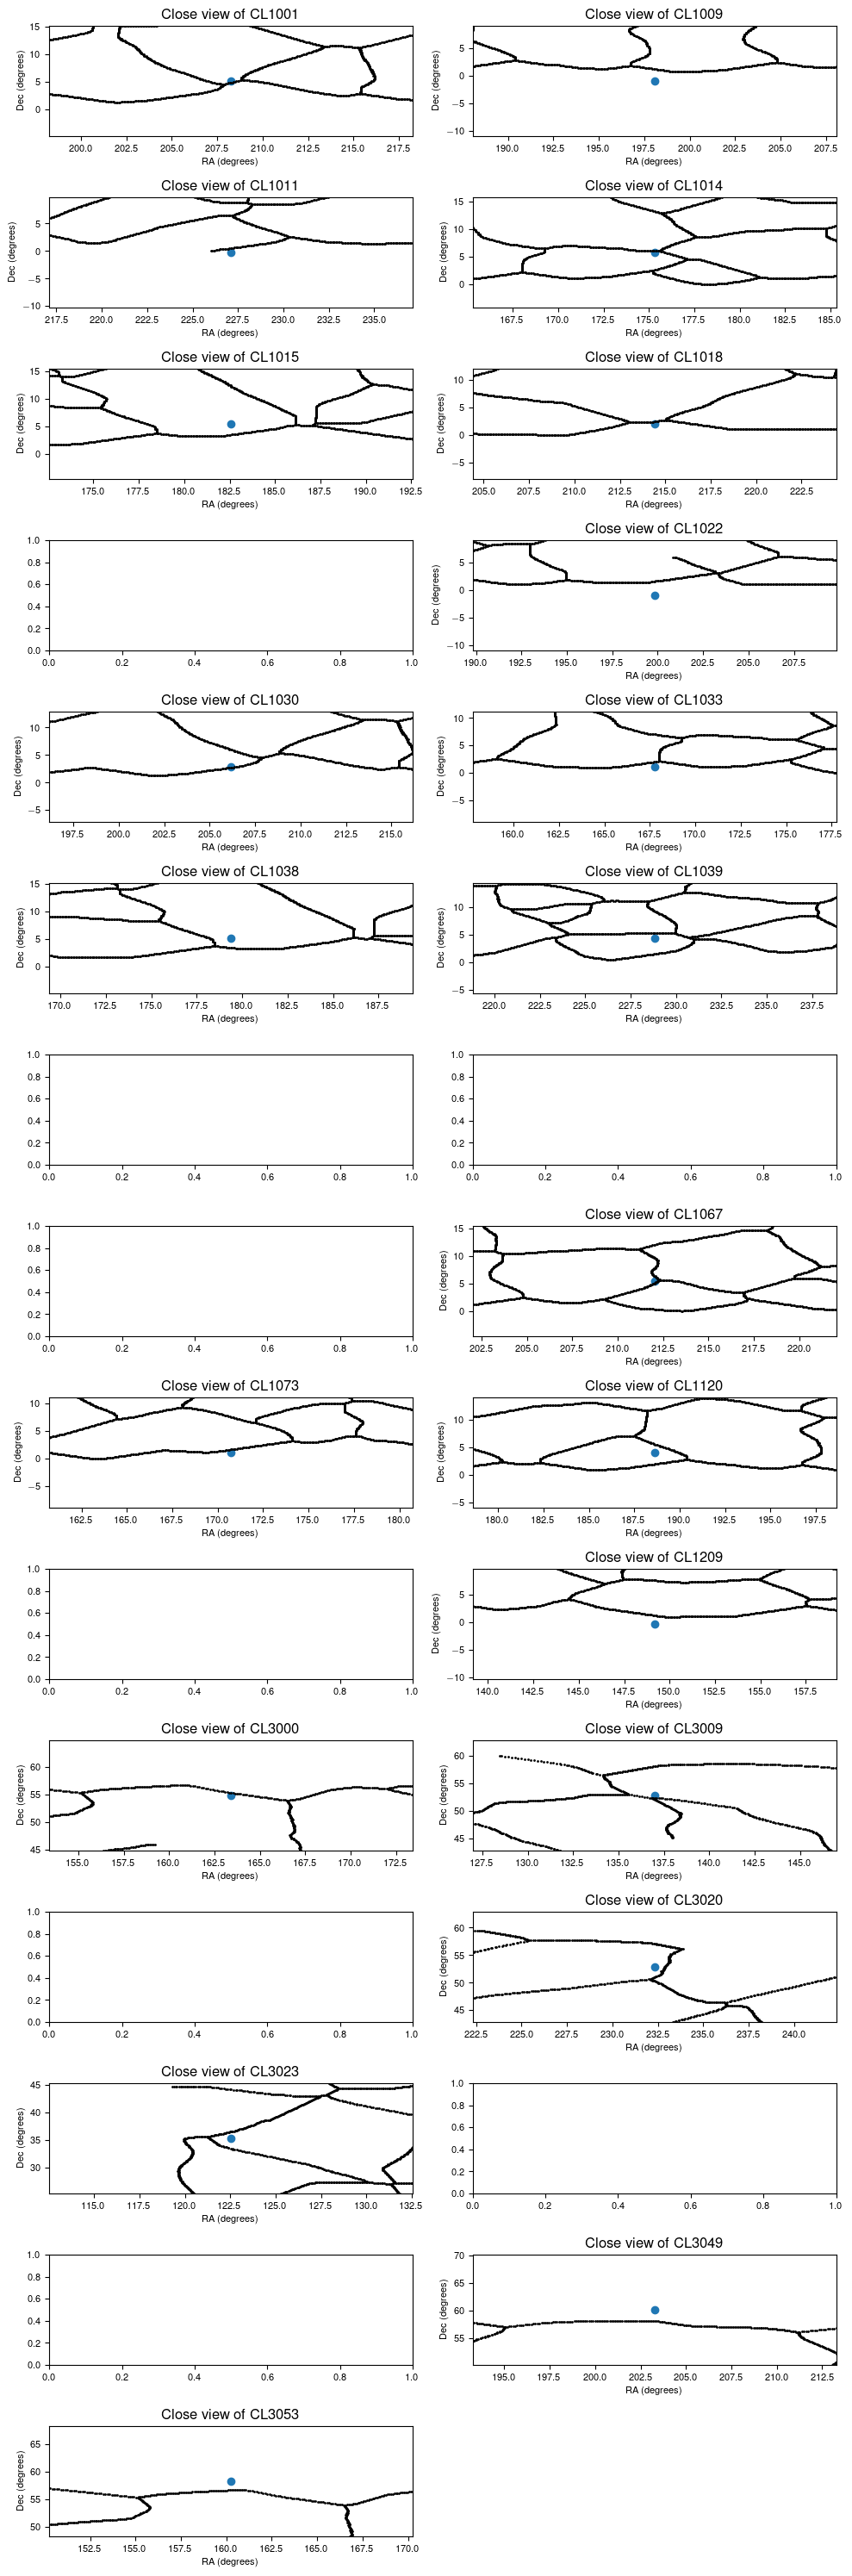

In [24]:
%%script false --no-raise-error
#Close ups of each point in Tarnopolski catalog
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()
fig, axs = plt.subplots(int(len(data_XUCS['Id'])/2 + 1), 2, figsize=(10, 30))

axs = axs.flatten()

for i in range(len(data_XUCS['Id'])):
    if mask[i] == True:
        x = data_XUCS.loc[i,'RAdeg']
        y = data_XUCS.loc[i,'DEdeg']
        axs[i].set_title(f"Close view of {data_XUCS.loc[i,'Id']}")
        axs[i].set_xlabel('RA (degrees)')
        axs[i].set_ylabel('Dec (degrees)')
        axs[i].scatter(x,y)
        z = data_XUCS.loc[i,'zLow']
        '''
        if(0.02 <= z <= 0.095):
            axs[i].scatter(df.loc[df['zLow'] == z, "RAdeg"], df.loc[df['zLow'] == z, "DEdeg"], color= 'black', s = 1)
        '''
        axs[i].scatter(data_filaments.loc[(data_filaments['Type'] == 'Filament') & (data_filaments['zLow'] >= z) & (data_filaments['zLow'] < (z + 0.005)),"RAdeg"], data_filaments.loc[(data_filaments['Type'] == 'Filament') & (data_filaments['zLow'] >= z) & (data_filaments['zLow'] < (z + 0.005)), "DEdeg"], color='black', s=1)
    
        axs[i].set_xlim(x-10, x+10)
        axs[i].set_ylim(y-10,y+10)
for j in range(i + 1, len(axs)):
    axs[j].axis('off')
plt.tight_layout()
plt.savefig('closeups_MT')

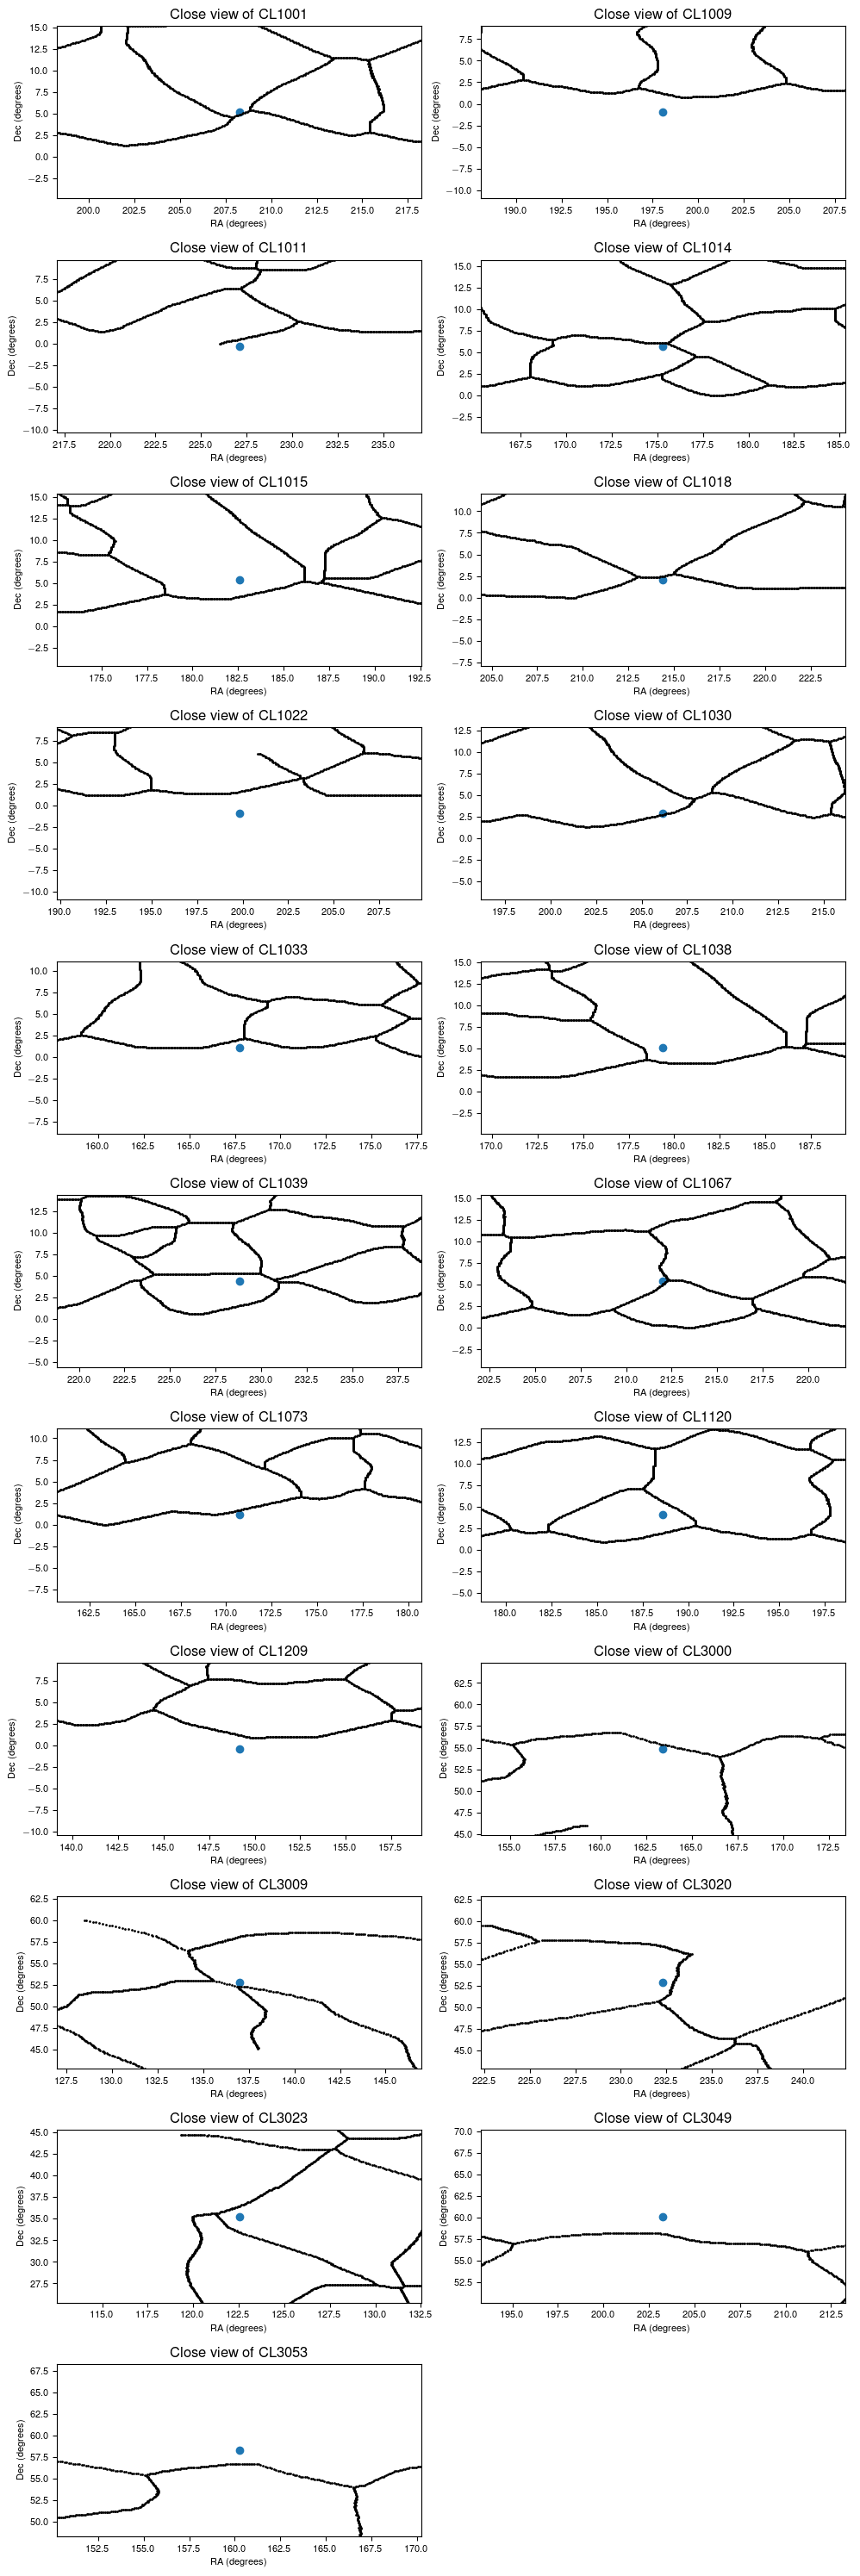

In [25]:
%%script false --no-raise-error
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

id_data = data_XUCS.loc[mask, 'Id'].reset_index(drop=True)
ra = data_XUCS.loc[mask, 'RAdeg'].reset_index(drop=True)
dec = data_XUCS.loc[mask, 'DEdeg'].reset_index(drop=True)
zlow = data_XUCS.loc[mask, 'zLow'].reset_index(drop=True)

fig, axs = plt.subplots(int(len(id_data)/2 + 1), 2, figsize=(10, 30))
axs = axs.flatten()

for i in range(len(id_data)):
    x = ra.iloc[i]
    y = dec.iloc[i]
    z = zlow.iloc[i]

    axs[i].set_title(f"Close view of {id_data.iloc[i]}")
    axs[i].set_xlabel('RA (degrees)')
    axs[i].set_ylabel('Dec (degrees)')

    # Plot the cluster/galaxy
    axs[i].scatter(x, y)

    # Plot nearby filaments
    fil_mask = (
        (data_filaments['Type'] == 'Filament') &
        (data_filaments['zLow'] >= z) &
        (data_filaments['zLow'] < z + 0.005)
    )

    axs[i].scatter(
        data_filaments.loc[fil_mask, 'RAdeg'],
        data_filaments.loc[fil_mask, 'DEdeg'],
        color='black',
        s=1
    )

    axs[i].set_xlim(x - 10, x + 10)
    axs[i].set_ylim(y - 10, y + 10)

# Turn off unused subplots
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.savefig('closeups_MT')

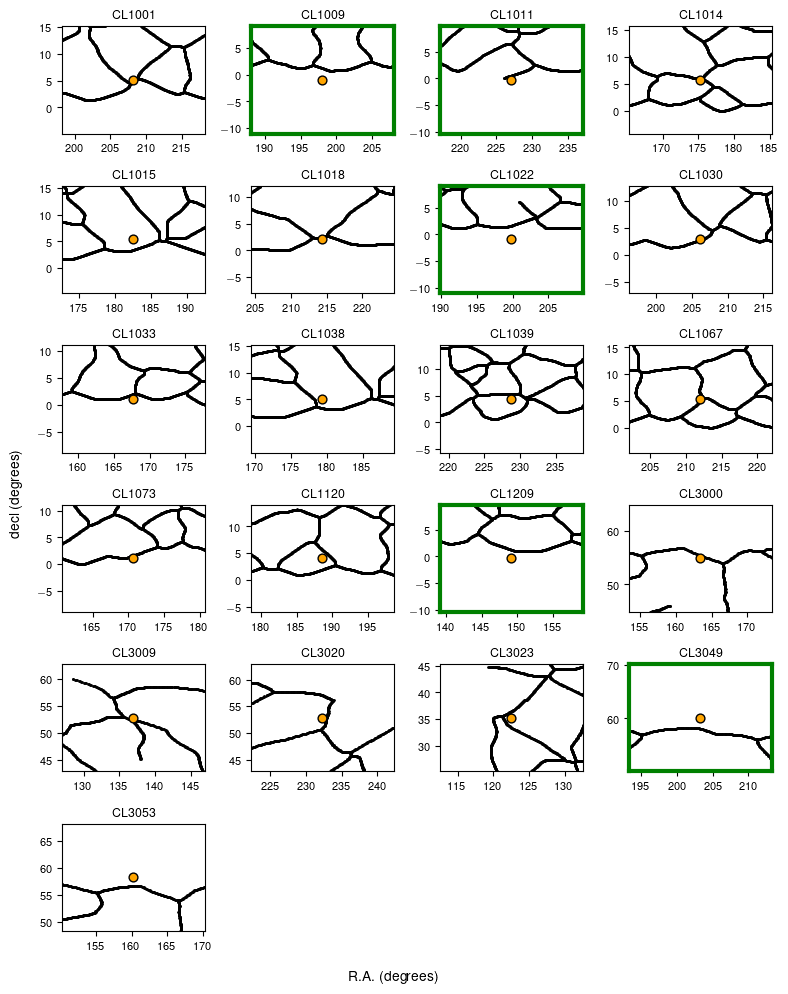

In [26]:
%%script false --no-raise-error
id_list = np.array(['CL1022','CL1209','CL1009','CL1011','CL3049'])

mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

id_data = data_XUCS.loc[mask, 'Id'].reset_index(drop=True)
ra = data_XUCS.loc[mask, 'RAdeg'].reset_index(drop=True)
dec = data_XUCS.loc[mask, 'DEdeg'].reset_index(drop=True)
zlow = data_XUCS.loc[mask, 'zLow'].reset_index(drop=True)
#int(len(id_data)/4 + 1)
fig, axs = plt.subplots(6, 4, figsize=(8, 10))
axs = axs.flatten()

fig.supxlabel('R.A. (degrees)', fontsize=10)
fig.supylabel('decl (degrees)', fontsize=10)

for i in range(len(id_data)):
    x = ra.iloc[i]
    y = dec.iloc[i]
    z = zlow.iloc[i]
    cid = id_data.iloc[i]

    
    axs[i].set_title(cid, fontsize=9)


    # Plot the cluster
    axs[i].scatter(x, y, s=40, color='orange', edgecolor='k', zorder=3)

    # Plot nearby filaments
    fil_mask = (
        (data_filaments['Type'] == 'Filament') &
        (data_filaments['zLow'] >= z) &
        (data_filaments['zLow'] < z + 0.005)
    )

    axs[i].scatter(
        data_filaments.loc[fil_mask, 'RAdeg'],
        data_filaments.loc[fil_mask, 'DEdeg'],
        color='black',
        s=1,
        zorder=1
    )

    axs[i].set_xlim(x - 10, x + 10)
    axs[i].set_ylim(y - 10, y + 10)

    # Thick border for selected IDs
    if cid in id_list:
        for spine in axs[i].spines.values():
            spine.set_linewidth(3)
            spine.set_edgecolor('green')

# Turn off unused subplots
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

'''
xlabel_size = plt.gca().xaxis.label.get_fontsize()
ylabel_size = plt.gca().yaxis.label.get_fontsize()
print(xlabel_size)
print(ylabel_size)
'''
plt.tight_layout()
plt.savefig('closeups_MT.pdf', dpi=300, bbox_inches='tight',format = 'pdf')


In [45]:
%%script false --no-raise-error
#Printing just some close-ups for publications (CL1022,1209,1009,1011,3049) <-- also, look at 3049 vs 3053
id_list = np.array(['CL1022','CL1209','CL1009','CL1011','CL3049'])
fig, axs = plt.subplots(int(len(id_list)/2 + 1), 2, figsize=(10, 30))

axs = axs.flatten()


for i in range(len(id_list)):
    if (data_XUCS.loc[i,'Id'] == id_list[i]):
        x = data_XUCS.loc[i,'RAdeg']
        y = data_XUCS.loc[i,'DEdeg']
        axs[i].set_title(f"Close view of {data_XUCS.loc[i,'Id']}")
        axs[i].set_xlabel('RA (degrees)')
        axs[i].set_ylabel('Dec (degrees)')
        axs[i].scatter(x,y)
        z = data_XUCS.loc[i,'zLow']
        '''
        if(0.02 <= z <= 0.095):
            axs[i].scatter(df.loc[df['zLow'] == z, "RAdeg"], df.loc[df['zLow'] == z, "DEdeg"], color= 'black', s = 1)
        '''
        axs[i].scatter(data_filaments.loc[(data_filaments['Type'] == 'Filament') & (data_filaments['zLow'] >= z) & (data_filaments['zLow'] < (z + 0.005)),"RAdeg"], data_filaments.loc[(data_filaments['Type'] == 'Filament') & (data_filaments['zLow'] >= z) & (data_filaments['zLow'] < (z + 0.005)), "DEdeg"], color='black', s=1)
    
        axs[i].set_xlim(x-10, x+10)
        axs[i].set_ylim(y-10,y+10)

plt.tight_layout()
plt.show()

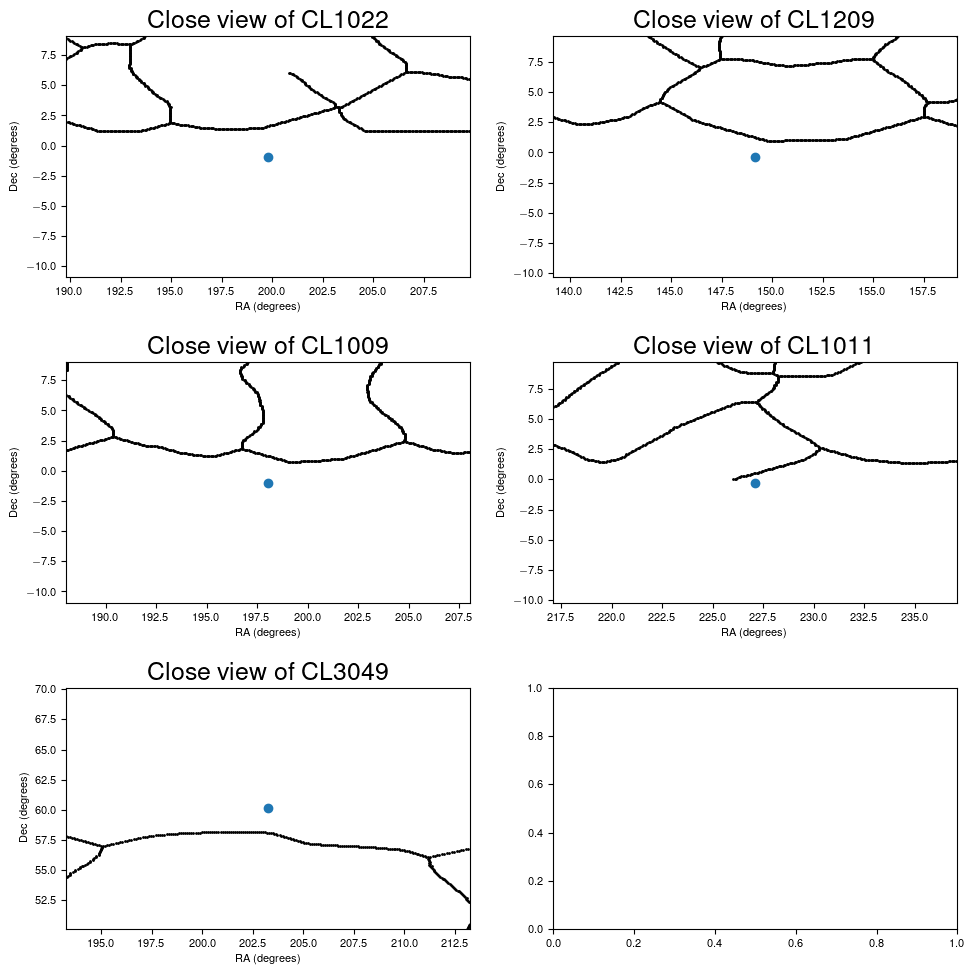

In [81]:
id_list = np.array(['CL1022','CL1209','CL1009','CL1011','CL3049'])

nrows = math.ceil(len(id_list) / 2)
fig, axs = plt.subplots(nrows, 2, figsize=(10, 10))
axs = axs.flatten()

plt.rcParams.update({
    "text.usetex": True,           # Enables full LaTeX rendering
    "font.family": "sans-serif",        # Matches the A&A serif style
    "font.sans-serif": ["Helvetica", "Arial"],
    "text.latex.preamble": r"\usepackage{helvet} \usepackage{sfmath}",
    "axes.labelsize": 8,       # For theta'(f) and f
    "xtick.labelsize": 8,      # For 0, pi, 2pi...
    "ytick.labelsize": 8,      # For 0.9, 1.0, 1.1...
    "legend.fontsize": 8,
    
    # Figure size for a single-column journal (3.5 inches wide)
    "figure.figsize": (3.5, 2.8)
})

for i, cid in enumerate(id_list):

    # --- Select the galaxy cluster row properly ---
    row = data_XUCS[data_XUCS['Id'] == cid]
    if row.empty:
        print(f"ID {cid} not found in data_XUCS.")
        continue

    row = row.iloc[0]  # the matched row

    x = row['RAdeg']
    y = row['DEdeg']
    z = row['zLow']

    axs[i].set_title(f"Close view of {cid}")
    axs[i].set_xlabel('RA (degrees)')
    axs[i].set_ylabel('Dec (degrees)')
    axs[i].scatter(x, y, label="Cluster")

    # --- Filament selection ---
    fil = data_filaments[
        (data_filaments['Type'] == 'Filament') &
        (data_filaments['zLow'] >= z) &
        (data_filaments['zLow'] < z + 0.005)
    ]

    axs[i].scatter(
        fil['RAdeg'], fil['DEdeg'], color='black', s=1, label="Filaments"
    )

    axs[i].set_xlim(x - 10, x + 10)
    axs[i].set_ylim(y - 10, y + 10)

plt.tight_layout()
plt.savefig('OoB_MT_Plots',format='pdf')



21
For #4a2377, Average: 6.559538249595827, Lower error bound: 4.405636875071411, Upper error bound: 8.713439624120245
For #8cc5e3, Average: 4.575178703449218, Lower error bound: 3.6873875256908035, Upper error bound: 5.462969881207632
For #f55f74, Average: 5.242641442068125, Lower error bound: 1.2044976553199866, Upper error bound: 9.280785228816264


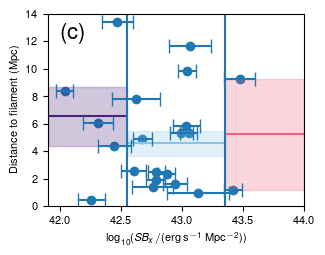

In [79]:
#Plotting surface brightness vs distance to MT for 21 points 
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

xDat = data_XUCS.loc[mask,'SB_Tarnopolski']
yDat = data_XUCS.loc[mask,'min_distance_to_filament_Haversin_MT (Mpc)']

plt.figure()
#plt.title('Surface Brightness vs Distance to Filaments, Tarnopolski')
plt.scatter(xDat, yDat)
print(len(xDat))
plt.errorbar(xDat,yDat,xerr= data_XUCS.loc[mask,'SB err'], linestyle='None', capsize=5)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel(r'$\log_{10}(SB_x / (\mathrm{erg\ s^{-1}\ Mpc^{-2}}))$')
plt.text(
    0.05, 0.95,
    '(c)',
    transform=plt.gca().transAxes,
    fontsize=16,
    va='top',
    ha='left'
)


lowSB = data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'min_distance_to_filament_Haversin_MT (Mpc)']
medSB = data_XUCS.loc[mask & (42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'min_distance_to_filament_Haversin_MT (Mpc)']
highSB = data_XUCS.loc[mask & (43.35 < data_XUCS['SB_Tarnopolski']), 'min_distance_to_filament_Haversin_MT (Mpc)']

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

#add vertical lines at 42.55 and 43.35
plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
plt.ylim(0,14)
plt.tight_layout()
plt.savefig('SBvsDist_MT_21.pdf',format = 'pdf',bbox_inches='tight')

For #4a2377, Average: 6.559538249595827, Lower error bound: 4.405636875071411, Upper error bound: 8.713439624120245
For #8cc5e3, Average: 4.575178703449218, Lower error bound: 3.6873875256908035, Upper error bound: 5.462969881207632
For #f55f74, Average: 5.242641442068125, Lower error bound: 1.2044976553199866, Upper error bound: 9.280785228816264


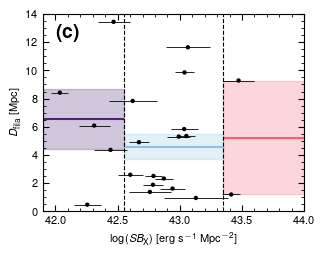

In [82]:
# Plotting surface brightness vs distance to MT for 21 points 
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

xDat = data_XUCS.loc[mask, 'SB_Tarnopolski']
yDat = data_XUCS.loc[mask, 'min_distance_to_filament_Haversin_MT (Mpc)']
plt.rcParams.update({
    "text.usetex": True,           # Enables full LaTeX rendering
    "font.family": "sans-serif",        # Matches the A&A serif style
    "font.sans-serif": ["Helvetica", "Arial"],
    "text.latex.preamble": r"\usepackage{helvet} \usepackage{sfmath}",
    "axes.labelsize": 8,       # For theta'(f) and f
    "xtick.labelsize": 8,      # For 0, pi, 2pi...
    "ytick.labelsize": 8,      # For 0.9, 1.0, 1.1...
    "legend.fontsize": 8,
    
    # Figure size for a single-column journal (3.5 inches wide)
    "figure.figsize": (3.5, 2.8)
})

# --- 1. SET PIXEL-PERFECT A&A STYLE ---
plt.figure()

# --- 2. CALCULATE CATEGORIES ---
lowSB = data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'min_distance_to_filament_Haversin_MT (Mpc)']
medSB = data_XUCS.loc[mask & (42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'min_distance_to_filament_Haversin_MT (Mpc)']
highSB = data_XUCS.loc[mask & (43.35 < data_XUCS['SB_Tarnopolski']), 'min_distance_to_filament_Haversin_MT (Mpc)']

# --- 3. PLOT ERROR REGIONS (Z-ORDER 1) ---
color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

# --- 4. MAIN DATA (Z-ORDER 2 & 3) ---
# Error bars behind dots
plt.errorbar(xDat, yDat, xerr=data_XUCS.loc[mask, 'SB err'], 
             linestyle='None', capsize=0, c='black', linewidth=0.6, zorder=2)

# Scatter dots on top
plt.scatter(xDat, yDat, c='black', s=10, zorder=3, edgecolors='none')

# Subplot label
plt.text(0.05, 0.95, r'\textbf{(c)}', transform=plt.gca().transAxes, 
         fontsize=14, va='top', ha='left', zorder=5)

# --- 5. AXES, TICKS & LABELS ---
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.tick_params(which='major', length=4, width=0.8)
plt.tick_params(which='minor', length=2, width=0.6)

plt.xlabel(r'$\log(SB_{\mathrm{X}}) \ [\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{Mpc}^{-2}]$')
plt.ylabel(r'$D_{\mathrm{fila}} \ [\mathrm{Mpc}]$')

# Vertical dividers
plt.axvline(x=42.55, c='black', linestyle='dashed', linewidth=0.8, zorder=1)
plt.axvline(x=43.35, c='black', linestyle='dashed', linewidth=0.8, zorder=1)

plt.xlim(41.9, 44)
plt.ylim(0, 14)

plt.tight_layout()
plt.savefig('SBvsDist_MT_21.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

For #4a2377, Average: 2.9083333333333328, Lower error bound: 2.072397065161862, Upper error bound: 3.7442696015048034
For #8cc5e3, Average: 1.7893333333333332, Lower error bound: 1.4665161704765226, Upper error bound: 2.112150496190144
For #f55f74, Average: 1.33125, Lower error bound: 1.0215759922572956, Upper error bound: 1.6409240077427045


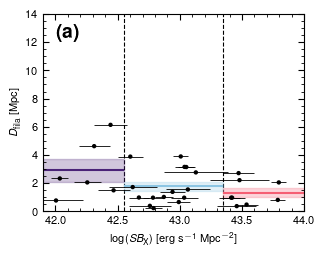

In [86]:
#literally why
# --- 2. DATA SEGMENTATION ---
lowSB = data_XUCS.loc[(data_XUCS['SB_Tarnopolski'] <= 42.55), 'Haversin_Dist_Zar (Mpc)']
medSB = data_XUCS.loc[(42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'Haversin_Dist_Zar (Mpc)']
highSB = data_XUCS.loc[43.35 < data_XUCS['SB_Tarnopolski'], 'Haversin_Dist_Zar (Mpc)']

# --- 3. PLOT ERROR REGIONS (Z-ORDER 1) ---
color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

# --- 4. DATA POINTS & ERROR BARS (Z-ORDER 2 & 3) ---
# Individual error bars (behind the points)
plt.errorbar(data_XUCS['SB_Tarnopolski'], data_XUCS['Haversin_Dist_Zar (Mpc)'], 
             xerr=data_XUCS['SB err'], linestyle='None', capsize=0, 
             c='black', linewidth=0.6, zorder=2)

# Individual scatter points (on top of bars)
plt.scatter(data_XUCS['SB_Tarnopolski'], data_XUCS['Haversin_Dist_Zar (Mpc)'], 
            c='black', s=10, zorder=3, edgecolors='none')

# Subplot label (a)
plt.text(0.05, 0.95, r'\textbf{(a)}', transform=plt.gca().transAxes, 
         fontsize=14, va='top', ha='left', zorder=5)

# --- 5. AXES & TICK STYLING (The "Science" Look) ---
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.tick_params(which='major', length=4, width=0.8)
plt.tick_params(which='minor', length=2, width=0.6)

# Properly formatted LaTeX labels
plt.xlabel(r'$\log(SB_{\mathrm{X}}) \ [\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{Mpc}^{-2}]$')
plt.ylabel(r'$D_{\mathrm{fila}} \ [\mathrm{Mpc}]$')

# --- 6. BOUNDARIES & LIMITS ---
plt.axvline(x=42.55, c='black', linestyle='dashed', linewidth=0.8, zorder=0)
plt.axvline(x=43.35, c='black', linestyle='dashed', linewidth=0.8, zorder=0)

plt.xlim(41.9, 44)
plt.ylim(0, 14)

plt.tight_layout()
plt.savefig('SBvsDist_Zarr_29.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Monte-Carlo Simulation

In [12]:
#has_overlap and monte_carlo_overlap functions
#validating result of zarattini paper
#monte-carlo simulation.
#data is an 3d array, only looks for overlap between a pair of sets


#Determines if all three groups overlap
#takes in an nd list of y values, list1, list2, and list3
def has_overlap(ndlist):
    #defines the list Intervals that will hold the upper and lower error bars in 3 lists of size 2
    intervals = []
    #checks if there is more than one region to compare (must be 2+ otherwise by default there is no overlap)
    if(len(ndlist) == 1):
        return False
    
    elif(len(ndlist) >= 2):
        #for each item in ndlist (that is each list of (e.g. 29) points), calculate the mean, standard deviaton, and error
        for i in range(len(ndlist)):
            count = np.count_nonzero(~np.isnan(ndlist[i]))
            mean = np.nanmean(ndlist[i])
            std = np.std(ndlist[i], ddof = 1)
            err = std/np.sqrt(count)
            #intervals: [(lowErr1, HighErr1)
            #            (lowErr2, HighErr2)
            #            (lowErr3, HighErr3)
            #            ...
            #            ]
            '''
            (1,2);(1,3);(2,3)
            adds one for each non-overlap
            '''
            a = [41.9,42.55,43.35]
            b = [42.55,43.35,44]
            color_count = i
            intervals.append((mean, mean-err, mean+err))

            #plot_errors(intervals[i], a[i], b[i])
        
        
        overlap_count = 0
        for (mean, low1, high1), (mean, low2, high2) in combinations(intervals, 2):
            if max(low1, low2) < min(high1, high2): 
                overlap_count += 1
        # Return True only if exactly one (or two) pair(s) overlap(s) (i.e. partial overlap) --> for non-overlaps, change to zero. (overlap_count ==0)
        return (overlap_count != 3)
    


def monte_carlo_overlap(numPts, runs):
    count2d = 0
    count3d = 0
    i=0
    while (i < runs):
        #plt.figure()
        x = [((random.random()*2.1) + 41.9) for i in range(numPts)]
        y = [(random.random()*14) for i in range(numPts)]
        #x = [random.random() for i in range(numPts)]
        #y = [random.random() for i in range(numPts)]
        list1 = [y[i] for i in range(len(x)) if 41.9 <= x[i] <= 42.55]
        list2 = [y[i] for i in range(len(x)) if 42.55 <= x[i] <= 43.35]
        list3 = [y[i] for i in range(len(x)) if 43.35 <= x[i] <= 44]
        #list1 = [y[i] for i in range(len(x)) if 0 <= x[i] <= 0.3095]
        #list2 = [y[i] for i in range(len(x)) if 0.3095 <= x[i] <= 0.6905]
        #list3 = [y[i] for i in range(len(x)) if 0.6905 <= x[i] <= 1]
        
        if (len(list1) > 1) & (len(list2) > 1) & (len(list3)>1):
            i += 1
            #twodlist = [list1,list2]
            threedlist = [list1,list2,list3]
            #if(has_overlap(twodlist) == True):
            #    count2d += 1
            if(has_overlap(threedlist) == True):
                count3d += 1

        #plt.scatter(x,y)
        
        
    return count3d/runs*100
    return f'probability of any pattern (not 3 boxes overlapping): {count3d/runs*100}%'

In [3]:
#NEW --> re-do of MC scheme
#checks decreasing as well as if there are exactly 2 overlaps (exact case of Zarattini paper)
def has_overlap_edited(ndlist):
    #defines the list Intervals that will hold the upper and lower error bars in 3 lists of size 2
    intervals = []
    #checks if there is more than one region to compare (must be 2+ otherwise by default there is no overlap)
    if(len(ndlist) == 1):
        return "Must input a 2D or higher list"
    
    elif(len(ndlist) >= 2):
        #for each item in ndlist (that is each list of (e.g. 29) points), calculate the mean, standard deviaton, and error
        for i in ndlist:
            count = np.count_nonzero(~np.isnan(i))
            mean = np.nanmean(i)
            std = np.std(i, ddof = 1)
            err = std/np.sqrt(count)
            #intervals: [(lowErr1, HighErr1)
            #            (lowErr2, HighErr2)
            #            (lowErr3, HighErr3)
            #            ...
            #            ]                                                                                                                                               
            '''
            (1,2);(1,3);(2,3)
            adds one for each non-overlap
            '''                             
            
            intervals.append((mean, mean - err, mean + err))
        
        
        overlap_count = 0
        decreasing_count = 0
        for (mean1, low1, high1), (mean2, low2, high2) in combinations(intervals, 2):
            if max(low1, low2) < min(high1, high2):
                overlap_count += 1
            if (mean1 > mean2):
                decreasing_count += 1
        # Return True only if exactly two pairs overlap (i.e. partial overlap)
        return (overlap_count <=2) & (decreasing_count == 3)

def monte_carlo_overlap_edited(numPts, runs):
    count3d = 0
    j = 0
    while(j<runs):
        x = [((random.random()*2.1) + 41.9) for i in range(numPts)]
        y = [(random.random()*14) for i in range(numPts)]
        list1 = [y[i] for i in range(len(x)) if 41.9 <= x[i] <= 42.55]
        list2 = [y[i] for i in range(len(x)) if 42.55 <= x[i] <= 43.35]
        list3 = [y[i] for i in range(len(x)) if 43.35 <= x[i] <= 44]

        if (len(list1) > 1) & (len(list2) > 1) & (len(list3)>1):
            j += 1
            threedlist = [list1,list2,list3]
           
            if(has_overlap_edited(threedlist) == True):
                count3d += 1
        
    return f'probability of two groups overlapping and one not and all decreasing: {count3d/runs*100}%'

In [4]:

#test of monte_carlo
print('29 random points')
print(monte_carlo_overlap(29,10000))
print('21 random points:')
print(monte_carlo_overlap(21,10000))
print('24 random points:')
print(monte_carlo_overlap(24,10000))
print('17 random points:')
print(monte_carlo_overlap(17,10000))

29 random points
38.05
21 random points:
40.26
24 random points:
39.15
17 random points:
42.89


In [151]:
#%%script false --no-raise-error
print(monte_carlo_overlap(10000,1000))
#seems to return 100 when all 3 dont overlap (there is a pattern), 0 when any overlap

probability of any pattern (not 3 boxes overlapping): 32.0%


In [47]:
#%%script false --no-raise-error

x3 = []
y3 = []

for i in range(9):
    z = (i+1)*10
    x3.append(z)
    y3.append(monte_carlo_overlap(z,10000))
for i in range(10):
    z = (i+1)*100
    x3.append(z)
    y3.append(monte_carlo_overlap(z,10000))
print(y)

[51.61, 40.87, 37.84, 36.02, 35.370000000000005, 35.03, 35.0, 34.9, 34.98, 33.89, 34.410000000000004, 34.14, 34.58, 32.83, 33.35, 34.089999999999996, 33.52, 33.660000000000004, 33.839999999999996]


In [48]:
print(x3)

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


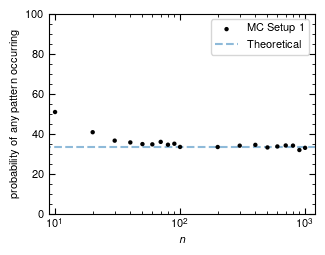

In [90]:
#n=10,20,30, ... ,100, 200, 300, ... 900, 1000 pts MC sim. plotted
#y = [84.45, 56.54, 45.64, 41.24, 38.76, 37.5, 37.169999999999995, 35.510000000000005, 34.949999999999996, 33.86, 34.06, 34.1, 33.03, 32.940000000000005, 34.150000000000006, 33.43, 33.47, 33.7, 33.78]
plt.scatter(x3,y3, c='black', s=10, zorder=3, edgecolors='none',label = 'MC Setup 1')
plt.rcParams.update({
    "text.usetex": True,           # Enables full LaTeX rendering
    "font.family": "sans-serif",        # Matches the A&A serif style
    "font.sans-serif": ["Helvetica", "Arial"],
    "text.latex.preamble": r"\usepackage{helvet} \usepackage{sfmath}",
    "axes.labelsize": 8,       # For theta'(f) and f
    "xtick.labelsize": 8,      # For 0, pi, 2pi...
    "ytick.labelsize": 8,      # For 0.9, 1.0, 1.1...
    "legend.fontsize": 8,
    
    # Figure size for a single-column journal (3.5 inches wide)
    "figure.figsize": (3.5, 2.8)
})
plt.xlabel(r'$n$')
plt.ylabel('probability of any pattern occurring')
n = 100/3
plt.hlines(n,-100,2000,linestyle='--',alpha=0.5,label='Theoretical')
plt.ylim((0,100))
plt.xlim((9,1200))
plt.xscale('log')
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.tick_params(which='major', length=4, width=0.8)
plt.tick_params(which='minor', length=2, width=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('percentPattern1.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [153]:
#%%script false --no-raise-error
for i in range(10):
    z = (i+1)*1000
    print(f'{z} runs:')
    print(monte_carlo_overlap(500,z))

1000 runs:
probability of any pattern (not 3 boxes overlapping): 33.1%
2000 runs:
probability of any pattern (not 3 boxes overlapping): 33.7%
3000 runs:
probability of any pattern (not 3 boxes overlapping): 34.13333333333333%
4000 runs:
probability of any pattern (not 3 boxes overlapping): 33.800000000000004%
5000 runs:
probability of any pattern (not 3 boxes overlapping): 33.86%
6000 runs:
probability of any pattern (not 3 boxes overlapping): 32.71666666666667%
7000 runs:
probability of any pattern (not 3 boxes overlapping): 34.385714285714286%
8000 runs:
probability of any pattern (not 3 boxes overlapping): 34.2125%
9000 runs:
probability of any pattern (not 3 boxes overlapping): 33.31111111111112%
10000 runs:
probability of any pattern (not 3 boxes overlapping): 33.21%


In [154]:
%%script false --no-raise-error
#test of monte_carlo
print('29 random points')
print(monte_carlo_overlap_edited(29,10000))
print('21 random points:')
print(monte_carlo_overlap_edited(21,10000))
print('24 random points:')
print(monte_carlo_overlap_edited(24,10000))
print('17 random points:')
print(monte_carlo_overlap_edited(17,10000))

In [32]:
#Test for zarattini paper, all 29 points
a = data_XUCS.loc[(data_XUCS['SB_Tarnopolski'] >= 41.9) & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'Haversin_Dist_Zar (Mpc)']
b = data_XUCS.loc[(data_XUCS['SB_Tarnopolski'] >= 42.55) & (data_XUCS['SB_Tarnopolski'] <= 43.35), 'Haversin_Dist_Zar (Mpc)']
c = data_XUCS.loc[(data_XUCS['SB_Tarnopolski'] >= 43.35) & (data_XUCS['SB_Tarnopolski'] <= 44.00), 'Haversin_Dist_Zar (Mpc)']
ndlist = [a,b,c]

print(f'Does the zarattini paper graph have a pattern? {has_overlap(ndlist)}')

Does the zarattini paper graph have a pattern? True


In [33]:
#Test for zarattini paper, 21 points
a = data_XUCS.loc[mask & (data_XUCS.loc[mask,'SB_Tarnopolski'] >= 41.9) & (data_XUCS.loc[mask,'SB_Tarnopolski'] <= 42.55), 'Haversin_Dist_Zar (Mpc)']
b = data_XUCS.loc[mask & (data_XUCS.loc[mask,'SB_Tarnopolski'] >= 42.55) & (data_XUCS.loc[mask,'SB_Tarnopolski'] <= 43.35), 'Haversin_Dist_Zar (Mpc)']
c = data_XUCS.loc[mask & (data_XUCS.loc[mask,'SB_Tarnopolski'] >= 43.35) & (data_XUCS.loc[mask,'SB_Tarnopolski'] <= 44.00), 'Haversin_Dist_Zar (Mpc)']
ndlist = [a,b,c]

print(f'Does the zarattini paper graph have at most two overlaps? {has_overlap(ndlist)}')

Does the zarattini paper graph have at most two overlaps? True


In [157]:
%%script false --no-raise-error
#29C21 monte_carlo experiment
#what is the percentage that, out of 29 random points, when you pick 21, you get 2 that overlap and one that does not?
count2d = 0
count3d = 0
runs = 10000
numPts = 29
for i in range(runs):
    x = data_XUCS['SB_Tarnopolski']
    y = data_XUCS['Haversin_Dist_Zar (Mpc)']
    
    chosen_idx = random.sample(range(numPts), 21)
    x_vals = [x[i] for i in chosen_idx]
    y_vals = [y[i] for i in chosen_idx]
    
    # get all values of y that correspond with the values of x chosen in each combination
    list1 = [y_vals[i] for i in range(21) if 41.9 <= x_vals[i] <= 42.55]
    list2 = [y_vals[i] for i in range(21) if 42.55 <= x_vals[i] <= 43.35]
    list3 = [y_vals[i] for i in range(21) if 43.35 <= x_vals[i] <= 44]
    
    threedlist = [list1,list2,list3]
    if(has_overlap(threedlist) == True):
        count3d += 1
        
print(f'Percentage of times you get 3 overlaps when choosing 21 from 29 {count3d/runs*100}%')


Carron Duque

In [13]:
#Loading Carrón Duque catalog Block 1
zlow = 0.06
data_block1 = pd.read_csv('Block1.csv', names = ['iterator','RAdeg','DEdeg','dens','unc','grad_RA','grad_dec','angle','zLow','zHigh','ini_dens'],skiprows = 1)
print(data_block1.loc[data_block1['zLow'] == zlow,'RAdeg'])

Series([], Name: RAdeg, dtype: float64)


In [14]:
#Loading full XUCS catalog (34 points)
XUCS_columns = ['Id', 'RAdeg', 'DEdeg', 'z', 'logM500caustic', 'errlogM500caustic', 
                'N', 'logM500veldisp', 'errlogM500veldisp', 'n', 'Telescope', 'texp', 
                'logLX', 'errlogLX', 'logLXce', 'errlogLXce']


data_XUCS_all = pd.read_csv('Andreon2016Data.csv',
                       skiprows=1,
                       names=XUCS_columns)

data_XUCS_all['Id'] = data_XUCS_all['Id'].str[2:]
data_XUCS_all = data_XUCS_all.sort_values('Id', axis = 0)
data_XUCS_all['Id'] = 'CL' + data_XUCS_all['Id']
data_XUCS_all = data_XUCS_all.reset_index(drop=True)



data_XUCS_all['zLow'] = np.floor(data_XUCS_all['z'] / 0.005) * 0.005
data_XUCS_all

,Id,RAdeg,DEdeg,z,logM500caustic,errlogM500caustic,N,logM500veldisp,errlogM500veldisp,n,Telescope,texp,logLX,errlogLX,logLXce,errlogLXce,zLow
0,CL1001,208.256,5.134,0.079,14.30,0.11,171,14.57,0.09,124,Swift,31.0,43.87,0.01,43.79,0.01,0.075
1,CL1009,198.057,-0.974,0.085,14.00,0.26,236,14.28,0.12,56,Chandra,20.9,43.38,0.01,43.24,0.02,0.085
2,CL1011,227.107,-0.266,0.091,14.23,0.17,48,14.46,0.14,42,Swift,13.7,42.96,0.05,42.77,0.07,0.090
3,CL1014,175.299,5.735,0.098,14.40,0.09,120,14.40,0.16,51,Swift,12.0,43.47,0.03,43.31,0.04,0.095
4,CL1015,182.570,5.386,0.077,13.85,0.19,79,14.14,0.15,37,Swift,17.3,43.65,0.01,43.55,0.01,0.075
5,CL1018,214.398,2.053,0.054,13.68,0.24,123,14.27,0.10,79,Swift,9.7,42.83,0.04,42.73,0.05,0.050
6,CL1020,176.028,5.798,0.103,13.94,0.35,29,14.61,0.14,43,Swift,6.8,43.74,0.02,43.61,0.03,0.100
7,CL1022,199.821,-0.919,0.083,13.86,0.12,87,13.56,0.16,36,XMM,31.2,42.55,0.10,42.55,0.10,0.080
8,CL1030,206.165,2.860,0.078,14.16,0.09,86,14.12,0.21,41,Swift,13.1,42.75,0.06,42.54,0.09,0.075
9,CL1033,167.747,1.128,0.097,13.83,0.12,77,13.79,0.21,20,Swift,9.0,43.15,0.04,43.05,0.05,0.095


Filament points found: 0
1     198.057
15    212.022
17    188.611
18    195.143
19    149.161
Name: RAdeg, dtype: float64


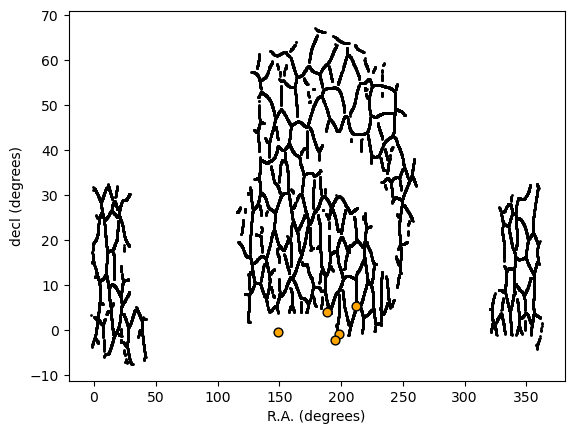

In [15]:
zlow = 0.085
print(f"Filament points found: {len(data_block1[data_block1['zLow'] == zlow])}")
plt.figure()

sel = (data_block1['zLow'] >= zlow) & (data_block1['zLow'] < zlow + 0.005)
plt.scatter(data_block1.loc[sel,'RAdeg'], data_block1.loc[sel,'DEdeg'],color='black', s=1,zorder = 3)
#plt.title('Reproduction of Filament Network created by Carron-Duque for zLow = 0.05')
plt.xlabel('R.A. (degrees)')
plt.ylabel('decl (degrees)')

plt.scatter(
    data_XUCS_all.loc[data_XUCS_all['zLow'] == zlow, 'RAdeg'],
    data_XUCS_all.loc[data_XUCS_all['zLow'] == zlow, 'DEdeg'],
    s=40,
    color='orange',
    label='XUCS clusters',
    zorder = 3,
    edgecolor='k'
)
print(data_XUCS_all.loc[data_XUCS_all['zLow'] == zlow, 'RAdeg'])

plt.savefig('CD_zLow085.pdf', dpi=300, bbox_inches='tight',format='pdf')

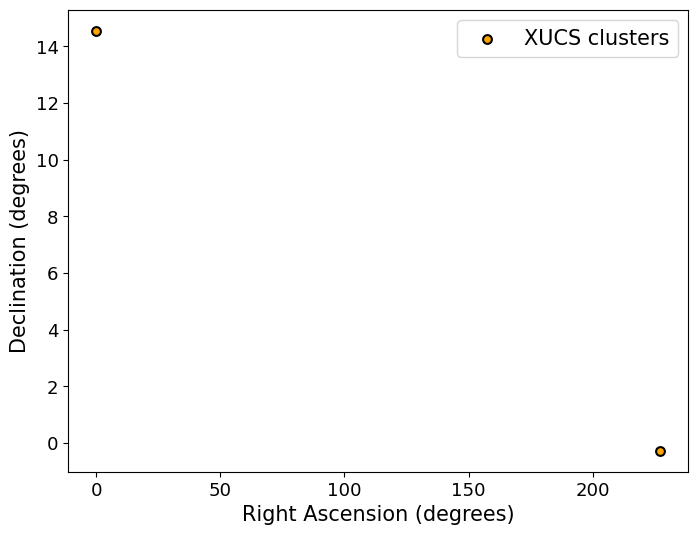

In [16]:
zlow = 0.09
tol = 1e-3

plt.figure(figsize=(8, 6))

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13
})

# Filament network
plt.scatter(
    data_block1.loc[np.abs(data_block1['zLow'] - zlow) < tol, 'RAdeg'],
    data_block1.loc[np.abs(data_block1['zLow'] - zlow) < tol, 'DEdeg'],
    s=1,
    color='black'
)

# XUCS clusters
mask = np.abs(data_XUCS_all['zLow'] - zlow) < tol
plt.scatter(data_XUCS_all.loc[mask, 'RAdeg'], data_XUCS_all.loc[mask, 'DEdeg'], s=40, color='orange',edgecolor='k', linewidth=1.5, label='XUCS clusters')

plt.xlabel('Right Ascension (degrees)')
plt.ylabel('Declination (degrees)')
plt.legend()

plt.savefig('CD_zLow08', format='pdf', bbox_inches='tight')
plt.show()


In [17]:
#changing RA and Dec points into euclidian and haversin distances to filaments using trees, Carron Duque
#make a loop so it does this for all zLow values
for i in range(50,140,5): #for comparison with our findings (17 pts) change to (20,100,5)
    z = i/1000
    x = int(i/5-4)
    zLow = i/1000
    #write out zLow and zHigh
    zHigh = zLow + 0.005
    
    #print(zLow)

    #Find filaments from filament catalog that are equal to zLow
    filaments_B1 = data_block1[(data_block1['zLow'] >= z) & (data_block1['zLow'] < (z+0.005))]

    #find clusters from the XUCS paper that are within 120<= RA <= 240, 0<= DE <= 60 and between zLow and zHigh
    XUCS_z = data_XUCS_all[(data_XUCS_all['RAdeg'] >= 0) &
                       (data_XUCS_all['RAdeg'] <= 360) &
                       (data_XUCS_all['z'] >= zLow) &
                       (data_XUCS_all['z'] < zHigh)
                      ]

    #use Kdtrees to find minimum distances between points in XUCS_z and filaments_z and add them to a column in data_XUCS_all
    ra_fil = filaments_B1['RAdeg'].values
    dec_fil = filaments_B1['DEdeg'].values
    ra_XUCS = XUCS_z['RAdeg'].values
    dec_XUCS = XUCS_z['DEdeg'].values
    coords_fil = np.vstack((ra_fil, dec_fil)).T
    tree = cKDTree(coords_fil)

    coords_XUCS = np.vstack((ra_XUCS, dec_XUCS)).T
    distances_Euclid, indices = tree.query(coords_XUCS)

    #print("Distances (in degrees) from each XUCS point to nearest filament:")
    #print("Euclidean distances=")
    #print(distances_Euclid)
    

    # Use the index from XUCS_z to map distances back to original DataFrame
    data_XUCS_all.loc[XUCS_z.index, 'block1_Euclid (degrees)'] = distances_Euclid
    
    
    #finds haversin distances from sky coordinate objects

    # Convert to SkyCoord objects
    coords_fil = SkyCoord(ra=ra_fil * u.deg, dec=dec_fil * u.deg)
    coords_XUCS = SkyCoord(ra=ra_XUCS * u.deg, dec=dec_XUCS * u.deg)

    # Compute closest angular distance for each XUCS point to any filament point
    # 'separation' returns angles; 'min()' gives closest match
    distances_Haversin = np.min(coords_XUCS[:,None].separation(coords_fil[None, :]).deg, axis=1)

    # Print distances in degrees
    #print("Angular distances=")
    #print(distances_Haversin)
    
    # Use the index from XUCS_z to map distances back to original DataFrame
    data_XUCS_all.loc[XUCS_z.index, 'block1_Haversin (degrees)'] = distances_Haversin

data_XUCS_all

,Id,RAdeg,DEdeg,z,logM500caustic,errlogM500caustic,N,logM500veldisp,errlogM500veldisp,n,Telescope,texp,logLX,errlogLX,logLXce,errlogLXce,zLow,block1_Euclid (degrees),block1_Haversin (degrees)
0,CL1001,208.256,5.134,0.079,14.30,0.11,171,14.57,0.09,124,Swift,31.0,43.87,0.01,43.79,0.01,0.075,1.069493,1.066410
1,CL1009,198.057,-0.974,0.085,14.00,0.26,236,14.28,0.12,56,Chandra,20.9,43.38,0.01,43.24,0.02,0.085,0.295084,0.295083
2,CL1011,227.107,-0.266,0.091,14.23,0.17,48,14.46,0.14,42,Swift,13.7,42.96,0.05,42.77,0.07,0.090,0.120239,0.120238
3,CL1014,175.299,5.735,0.098,14.40,0.09,120,14.40,0.16,51,Swift,12.0,43.47,0.03,43.31,0.04,0.095,0.540302,0.538040
4,CL1015,182.570,5.386,0.077,13.85,0.19,79,14.14,0.15,37,Swift,17.3,43.65,0.01,43.55,0.01,0.075,1.250278,1.246329
5,CL1018,214.398,2.053,0.054,13.68,0.24,123,14.27,0.10,79,Swift,9.7,42.83,0.04,42.73,0.05,0.050,0.514827,0.514497
6,CL1020,176.028,5.798,0.103,13.94,0.35,29,14.61,0.14,43,Swift,6.8,43.74,0.02,43.61,0.03,0.100,0.238535,0.237376
7,CL1022,199.821,-0.919,0.083,13.86,0.12,87,13.56,0.16,36,XMM,31.2,42.55,0.10,42.55,0.10,0.080,0.222622,0.222619
8,CL1030,206.165,2.860,0.078,14.16,0.09,86,14.12,0.21,41,Swift,13.1,42.75,0.06,42.54,0.09,0.075,0.300263,0.300183
9,CL1033,167.747,1.128,0.097,13.83,0.12,77,13.79,0.21,20,Swift,9.0,43.15,0.04,43.05,0.05,0.095,2.916382,2.915871


In [18]:
#Changing degrees to MpC

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

transverse = []
for i in range(len(data_XUCS_all)):
    # θ in degrees
    theta_deg = data_XUCS_all.loc[i,'block1_Haversin (degrees)']
    z = data_XUCS_all.loc[i, 'zLow']
    z = z + 0.0025

    # Convert θ to radians
    theta_rad = np.deg2rad(theta_deg)

    # proper distance in Mpc
    prop_dist = proper_distance(z) 

    # Angular diameter distance
    D_A = prop_dist / (1 + z)

    # Transverse physical distance in Mpc
    transverse_distance = theta_rad * D_A
    
    transverse.append(transverse_distance)

data_XUCS_all['block1_Haversin (Mpc)'] = transverse

In [19]:
#Uses above functions to add SB and SB err to dataframe
#H01 = 2.1713*(10**(-18)) <- presumably this is for 70 and the one below is ofr 73.
H01 = 2.26853*(10**(-18))
surface_brightness(data_XUCS_all,'block1_Haversin (Mpc)','SB_Carron_Duque',H01)
error_in_SB(data_XUCS_all)
data_XUCS_all

,Id,RAdeg,DEdeg,z,logM500caustic,errlogM500caustic,N,logM500veldisp,errlogM500veldisp,n,...,logLX,errlogLX,logLXce,errlogLXce,zLow,block1_Euclid (degrees),block1_Haversin (degrees),block1_Haversin (Mpc),SB_Carron_Duque,SB err
0,CL1001,208.256,5.134,0.079,14.30,0.11,171,14.57,0.09,124,...,43.87,0.01,43.79,0.01,0.075,1.069493,1.066410,5.631853,43.412787,0.074012
1,CL1009,198.057,-0.974,0.085,14.00,0.26,236,14.28,0.12,56,...,43.38,0.01,43.24,0.02,0.085,0.295084,0.295083,1.739156,43.064481,0.174483
2,CL1011,227.107,-0.266,0.091,14.23,0.17,48,14.46,0.14,42,...,42.96,0.05,42.77,0.07,0.090,0.120239,0.120238,0.744838,42.442852,0.133208
3,CL1014,175.299,5.735,0.098,14.40,0.09,120,14.40,0.16,51,...,43.47,0.03,43.31,0.04,0.095,0.540302,0.538040,3.493001,42.871517,0.072111
4,CL1015,182.570,5.386,0.077,13.85,0.19,79,14.14,0.15,37,...,43.65,0.01,43.55,0.01,0.075,1.250278,1.246329,6.582029,43.472224,0.127061
5,CL1018,214.398,2.053,0.054,13.68,0.24,123,14.27,0.10,79,...,42.83,0.04,42.73,0.05,0.050,0.514827,0.514497,1.895414,42.759156,0.167631
6,CL1020,176.028,5.798,0.103,13.94,0.35,29,14.61,0.14,43,...,43.74,0.02,43.61,0.03,0.100,0.238535,0.237376,1.610829,43.479618,0.235254
7,CL1022,199.821,-0.919,0.083,13.86,0.12,87,13.56,0.16,36,...,42.55,0.10,42.55,0.10,0.080,0.222622,0.222619,1.244283,42.467249,0.128062
8,CL1030,206.165,2.860,0.078,14.16,0.09,86,14.12,0.21,41,...,42.75,0.06,42.54,0.09,0.075,0.300263,0.300183,1.585304,42.255838,0.108167
9,CL1033,167.747,1.128,0.097,13.83,0.12,77,13.79,0.21,20,...,43.15,0.04,43.05,0.05,0.095,2.916382,2.915871,18.930093,42.991231,0.094340


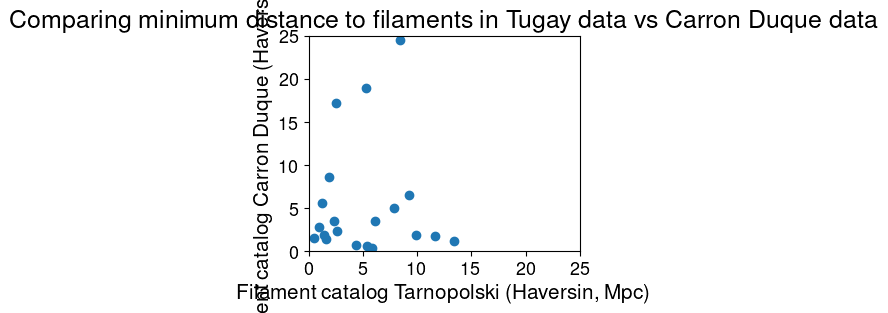

In [39]:
#Plotting distances to Tarnopolski catalog against distances to Carron Duque catalog
plt.figure()
data_XUCS['block1_Haversin (Mpc)'] = data_XUCS['Id'].map(data_XUCS_all.set_index('Id')['block1_Haversin (Mpc)'])
mask2 = ~data_XUCS['block1_Haversin (Mpc)'].isna()
xPts = data_XUCS.loc[mask2,'min_distance_to_filament_Haversin_MT (Mpc)']
yPts = data_XUCS.loc[mask2, 'block1_Haversin (Mpc)']

plt.scatter(xPts,yPts)
plt.title('Comparing minimum distance to filaments in Tugay data vs Carron Duque data')
plt.xlabel('Filament catalog Tarnopolski (Haversin, Mpc)')
plt.ylabel('Filament catalog Carron Duque (Haversin, Mpc)')
plt.xlim(0,25)
plt.ylim(0,25)
plt.show()

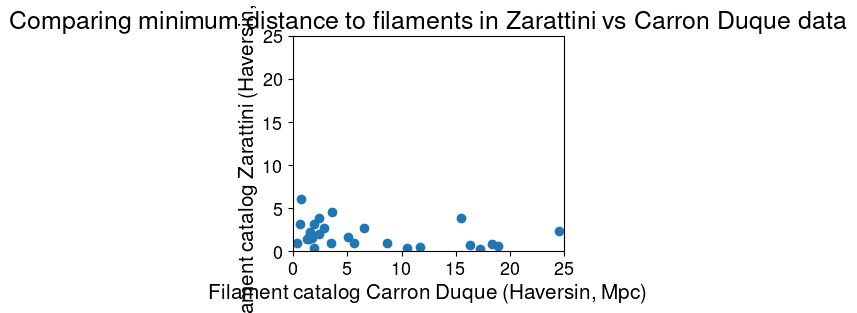

In [40]:
#Plotting distances to Carron Duque catalog against distances to Zarattini catalog
plt.figure()
data_XUCS['block1_Haversin (Mpc)'] = data_XUCS['Id'].map(data_XUCS_all.set_index('Id')['block1_Haversin (Mpc)'])
mask2 = ~data_XUCS['block1_Haversin (Mpc)'].isna()
xPts = data_XUCS.loc[mask2,'block1_Haversin (Mpc)']
yPts = data_XUCS.loc[mask2, 'Haversin_Dist_Zar (Mpc)']

plt.scatter(xPts,yPts)
plt.title('Comparing minimum distance to filaments in Zarattini vs Carron Duque data')
plt.xlabel('Filament catalog Carron Duque (Haversin, Mpc)')
plt.ylabel('Filament catalog Zarattini (Haversin, Mpc)')
plt.xlim(0,25)
plt.ylim(0,25)
plt.show()

In [41]:
data_XUCS_all

,Id,RAdeg,DEdeg,z,logM500caustic,errlogM500caustic,N,logM500veldisp,errlogM500veldisp,n,...,logLX,errlogLX,logLXce,errlogLXce,zLow,block1_Euclid (degrees),block1_Haversin (degrees),block1_Haversin (Mpc),SB_Carron_Duque,SB err
0,CL1001,208.256,5.134,0.079,14.30,0.11,171,14.57,0.09,124,...,43.87,0.01,43.79,0.01,0.075,1.069493,1.066410,5.631853,43.412787,0.074012
1,CL1009,198.057,-0.974,0.085,14.00,0.26,236,14.28,0.12,56,...,43.38,0.01,43.24,0.02,0.085,0.295084,0.295083,1.739156,43.064481,0.174483
2,CL1011,227.107,-0.266,0.091,14.23,0.17,48,14.46,0.14,42,...,42.96,0.05,42.77,0.07,0.090,0.120239,0.120238,0.744838,42.442852,0.133208
3,CL1014,175.299,5.735,0.098,14.40,0.09,120,14.40,0.16,51,...,43.47,0.03,43.31,0.04,0.095,0.540302,0.538040,3.493001,42.871517,0.072111
4,CL1015,182.570,5.386,0.077,13.85,0.19,79,14.14,0.15,37,...,43.65,0.01,43.55,0.01,0.075,1.250278,1.246329,6.582029,43.472224,0.127061
5,CL1018,214.398,2.053,0.054,13.68,0.24,123,14.27,0.10,79,...,42.83,0.04,42.73,0.05,0.050,0.514827,0.514497,1.895414,42.759156,0.167631
6,CL1020,176.028,5.798,0.103,13.94,0.35,29,14.61,0.14,43,...,43.74,0.02,43.61,0.03,0.100,0.238535,0.237376,1.610829,43.479618,0.235254
7,CL1022,199.821,-0.919,0.083,13.86,0.12,87,13.56,0.16,36,...,42.55,0.10,42.55,0.10,0.080,0.222622,0.222619,1.244283,42.467249,0.128062
8,CL1030,206.165,2.860,0.078,14.16,0.09,86,14.12,0.21,41,...,42.75,0.06,42.54,0.09,0.075,0.300263,0.300183,1.585304,42.255838,0.108167
9,CL1033,167.747,1.128,0.097,13.83,0.12,77,13.79,0.21,20,...,43.15,0.04,43.05,0.05,0.095,2.916382,2.915871,18.930093,42.991231,0.094340


For #4a2377, Average: 11.584959460353625, Lower error bound: 7.104131710062995, Upper error bound: 16.065787210644256
For #8cc5e3, Average: 7.100530698463565, Lower error bound: 4.90684246251235, Upper error bound: 9.29421893441478
For #f55f74, Average: 13.408501899822394, Lower error bound: 7.7691987201844865, Upper error bound: 19.0478050794603


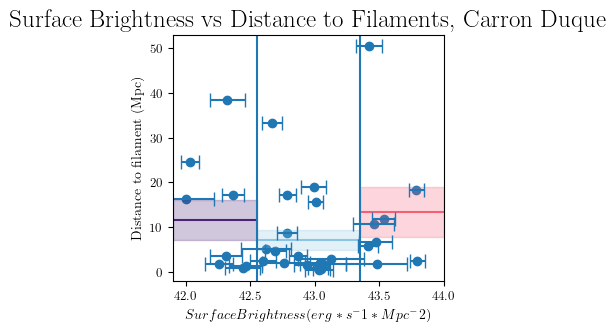

In [25]:
#plotting a Distance vs SB, includes individual horizontal and total mean error bars (all 34 points)
plt.figure()
plt.title('Surface Brightness vs Distance to Filaments, Carron Duque')
plt.scatter(data_XUCS_all['SB_Carron_Duque'],data_XUCS_all['block1_Haversin (Mpc)'])
plt.errorbar(data_XUCS_all['SB_Carron_Duque'],data_XUCS_all['block1_Haversin (Mpc)'],xerr= data_XUCS_all['SB err'], linestyle='None', capsize=5)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('$Surface Brightness (erg * s^-1 * Mpc^-2)$')
#add vertical lines at 42.55 and 43.35

lowSB = data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'block1_Haversin (Mpc)']
medSB = data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'block1_Haversin (Mpc)']
highSB = data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'block1_Haversin (Mpc)']

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
#plt.ylim(0,7)
plt.savefig('SBvsDist_CD_34',format='pdf') 

In [26]:
#drops specific values that are outside of the range of the carron-duque data
to_drop = ['CL1020','CL1047','CL2007','CL2010','CL2015','CL2045','CL2081','CL3013','CL3030','CL3046']
to_drop_restricted = ['CL1020','CL1047','CL2007','CL2010','CL2015','CL2045','CL2081','CL3013','CL3030','CL3046',"CL1033", "CL1041", "CL1052", "CL1073", "CL1132", "CL1209", "CL3023"]

data_XUCS_all['filtered_Mpc_Vals'] = data_XUCS_all.loc[~data_XUCS_all['Id'].isin(to_drop),'block1_Haversin (Mpc)']
data_XUCS_all['restricted_fil_Mpc_Vals'] = data_XUCS_all.loc[~data_XUCS_all['Id'].isin(to_drop_restricted),'block1_Haversin (Mpc)']

For #4a2377, Average: 7.997411300025159, Lower error bound: 3.9100365205093963, Upper error bound: 12.084786079540923
For #8cc5e3, Average: 7.691931794181562, Lower error bound: 5.245694362047617, Upper error bound: 10.138169226315506
For #f55f74, Average: 10.174523466607248, Lower error bound: 6.097703463866357, Upper error bound: 14.25134346934814
34


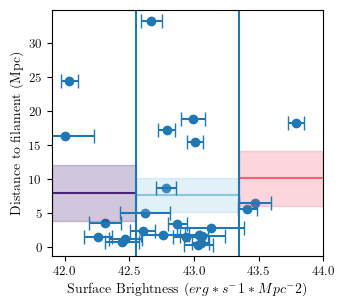

In [27]:
#plotting a Distance vs SB, includes individual horizontal and total mean error bars (24 points)
plt.figure()
#plt.title('Surface Brightness vs Distance to Filaments, Carron-Duque, filtered')
plt.scatter(data_XUCS_all['SB_Carron_Duque'],data_XUCS_all['filtered_Mpc_Vals'])
plt.errorbar(data_XUCS_all['SB_Carron_Duque'],data_XUCS_all['filtered_Mpc_Vals'],xerr= data_XUCS_all['SB err'], linestyle='None', capsize=5)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('Surface Brightness $(erg * s^-1 * Mpc^-2)$')
#add vertical lines at 42.55 and 43.35

lowSB = data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'filtered_Mpc_Vals']
medSB = data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'filtered_Mpc_Vals']
highSB = data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'filtered_Mpc_Vals']

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
print(len(data_XUCS_all['filtered_Mpc_Vals']))
#plt.ylim(0,7)
plt.savefig('SBvsDist_CD_24',format='pdf')

For #4a2377, Average: 7.997411300025159, Lower error bound: 3.9100365205093963, Upper error bound: 12.084786079540923
For #8cc5e3, Average: 7.691931794181562, Lower error bound: 5.245694362047617, Upper error bound: 10.138169226315506
For #f55f74, Average: 10.174523466607248, Lower error bound: 6.097703463866357, Upper error bound: 14.25134346934814
34


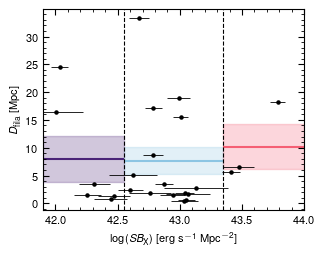

In [28]:
# Distance vs Surface Brightness (Carron–Duque) 24 points
plt.rcParams.update({
    "text.usetex": True,           # Enables full LaTeX rendering
    "font.family": "sans-serif",        # Matches the A&A serif style
    "font.sans-serif": ["Helvetica", "Arial"],
    "text.latex.preamble": r"\usepackage{helvet} \usepackage{sfmath}",
    "axes.labelsize": 8,       # For theta'(f) and f
    "xtick.labelsize": 8,      # For 0, pi, 2pi...
    "ytick.labelsize": 8,      # For 0.9, 1.0, 1.1...
    "legend.fontsize": 8,
    
    # Figure size for a single-column journal (3.5 inches wide)
    "figure.figsize": (3.5, 2.8)
})
plt.figure()
# Scatter points
plt.scatter(
    data_XUCS_all['SB_Carron_Duque'],
    data_XUCS_all['filtered_Mpc_Vals'],
    s=5,
    zorder=3,
    c='black'
)

# Horizontal error bars
plt.errorbar(
    data_XUCS_all['SB_Carron_Duque'],
    data_XUCS_all['filtered_Mpc_Vals'],
    xerr=data_XUCS_all['SB err'],
    linestyle='None',
    capsize=0,
    zorder=2,
    c = 'black',
    linewidth = 0.6
)

# Axis labels
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.tick_params(which='major', length=4, width=0.8)
plt.tick_params(which='minor', length=2, width=0.6)

plt.xlabel(r'$\log(SB_{\mathrm{X}}) \ [\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{Mpc}^{-2}]$')

plt.ylabel(r'$D_{\mathrm{fila}} \ [\mathrm{Mpc}]$')

# Define SB bins
lowSB = data_XUCS_all.loc[
    data_XUCS_all['SB_Carron_Duque'] <= 42.55,
    'filtered_Mpc_Vals'
]

medSB = data_XUCS_all.loc[
    (data_XUCS_all['SB_Carron_Duque'] > 42.55) &
    (data_XUCS_all['SB_Carron_Duque'] <= 43.35),
    'filtered_Mpc_Vals'
]

highSB = data_XUCS_all.loc[
    data_XUCS_all['SB_Carron_Duque'] > 43.35,
    'filtered_Mpc_Vals'
]

# Mean + error bars per bin
color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

# Vertical bin boundaries
plt.axvline(42.55, linestyle='--', linewidth=0.8,c='black')
plt.axvline(43.35, linestyle='--', linewidth=0.8,c='black')

# Axis limits
plt.xlim(41.9, 44)
# ax.set_ylim(0, 7)

print(len(data_XUCS_all['filtered_Mpc_Vals']))

plt.tight_layout()
plt.savefig('SBvsDist_CD_24.pdf', dpi=300, bbox_inches='tight')

For #4a2377, Average: 1.7826885565012418, Lower error bound: 1.1668031223710078, Upper error bound: 2.398573990631476
For #8cc5e3, Average: 2.7649827362686876, Lower error bound: 2.056167638971251, Upper error bound: 3.4737978335661244
For #f55f74, Average: 6.10694124666797, Lower error bound: 5.631853195517195, Upper error bound: 6.582029297818744


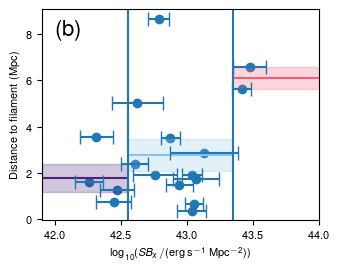

In [37]:
#plotting Distance vs logSBx, includes individual horizontal and total mean error bars (CD 17 points)
plt.figure()
#plt.title('Surface Brightness vs Distance to Filaments, Carron-Duque, filtered')
plt.scatter(data_XUCS_all['SB_Carron_Duque'],data_XUCS_all['restricted_fil_Mpc_Vals'])
plt.errorbar(data_XUCS_all['SB_Carron_Duque'],data_XUCS_all['restricted_fil_Mpc_Vals'],xerr= data_XUCS_all['SB err'], linestyle='None', capsize=5)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel(r'$\log_{10}(SB_x / (\mathrm{erg\ s^{-1}\ Mpc^{-2}}))$')
#add vertical lines at 42.55 and 43.35
plt.text(
    0.05, 0.95,
    '(b)',
    transform=plt.gca().transAxes,
    fontsize=16,
    va='top',
    ha='left'
)

lowSB = data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'restricted_fil_Mpc_Vals']
medSB = data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'restricted_fil_Mpc_Vals']
highSB = data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'restricted_fil_Mpc_Vals']

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
#plt.ylim(0,7)
plt.tight_layout()
plt.savefig('SBvsDist_CD_17.pdf',format = 'pdf', bbox_inches='tight')

For #4a2377, Average: 1.7826885565012418, Lower error bound: 1.1668031223710078, Upper error bound: 2.398573990631476
For #8cc5e3, Average: 2.7649827362686876, Lower error bound: 2.056167638971251, Upper error bound: 3.4737978335661244
For #f55f74, Average: 6.10694124666797, Lower error bound: 5.631853195517195, Upper error bound: 6.582029297818744


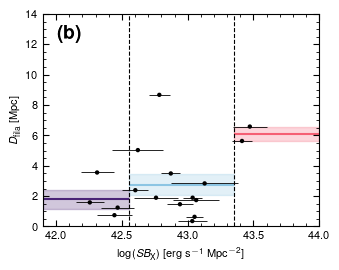

In [38]:
# plotting Distance vs logSBx, includes individual horizontal and total mean error bars (CD 17 points)
plt.figure()

# --- 2. DEFINE CATEGORIES ---
lowSB = data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'restricted_fil_Mpc_Vals']
medSB = data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'restricted_fil_Mpc_Vals']
highSB = data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'restricted_fil_Mpc_Vals']

# --- 3. BACKGROUND ERROR REGIONS (Z-ORDER 1) ---
color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

# --- 4. MAIN DATA (Z-ORDER 2 & 3) ---
# Error bars (no caps for a cleaner look)
plt.errorbar(data_XUCS_all['SB_Carron_Duque'], data_XUCS_all['restricted_fil_Mpc_Vals'], 
             xerr=data_XUCS_all['SB err'], linestyle='None', capsize=0, 
             c='black', linewidth=0.6, zorder=2)

# Scatter points
plt.scatter(data_XUCS_all['SB_Carron_Duque'], data_XUCS_all['restricted_fil_Mpc_Vals'], 
            c='black', s=10, zorder=3, edgecolors='none')

# Subplot label (b)
plt.text(0.05, 0.95, r'\textbf{(b)}', transform=plt.gca().transAxes, 
         fontsize=14, va='top', ha='left', zorder=5)

# --- 5. AXES, TICKS & LABELS ---
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.tick_params(which='major', length=4, width=0.8)
plt.tick_params(which='minor', length=2, width=0.6)

plt.xlabel(r'$\log(SB_{\mathrm{X}}) \ [\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{Mpc}^{-2}]$')

plt.ylabel(r'$D_{\mathrm{fila}} \ [\mathrm{Mpc}]$')

# Vertical dividers
plt.axvline(x=42.55, c='black', linestyle='dashed', linewidth=0.8, zorder=1)
plt.axvline(x=43.35, c='black', linestyle='dashed', linewidth=0.8, zorder=1)

plt.xlim(41.9, 44)
plt.ylim(0, 14) # Uncomment to force the same scale as plot (a)

plt.tight_layout()
plt.savefig('SBvsDist_CD_17.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

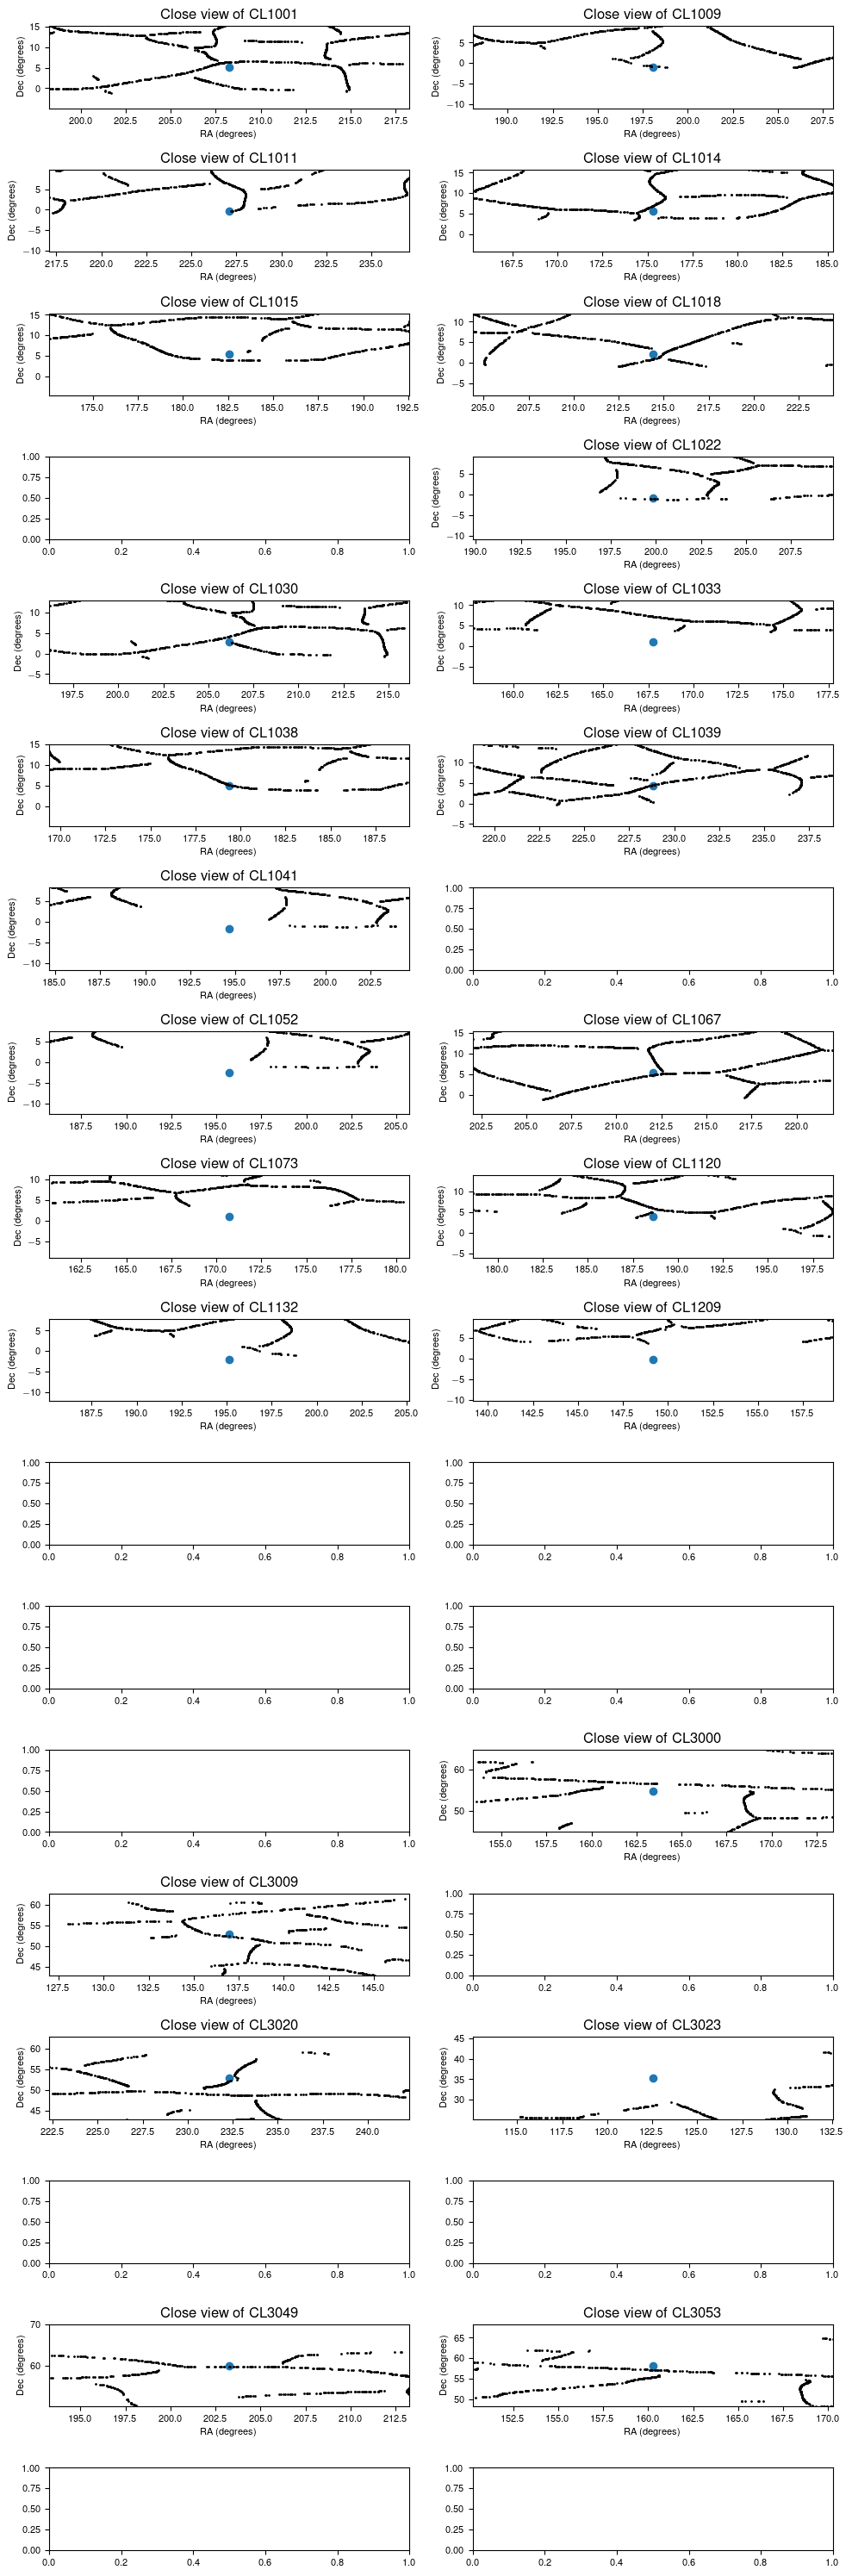

In [39]:
#Close ups of each point in CD catalog
mask = ~data_XUCS_all['filtered_Mpc_Vals'].isna()
fig, axs = plt.subplots(int(len(data_XUCS_all['Id'])/2 + 1), 2, figsize=(10, 30))

axs = axs.flatten()

for i in range(len(data_XUCS_all['Id'])):
    if mask.iloc[i]:
        x = data_XUCS_all.loc[i,'RAdeg']
        y = data_XUCS_all.loc[i,'DEdeg']
        axs[i].set_title(f"Close view of {data_XUCS_all.loc[i,'Id']}")
        axs[i].set_xlabel('RA (degrees)')
        axs[i].set_ylabel('Dec (degrees)')
        axs[i].scatter(x,y)
        zlow = data_XUCS_all.loc[i,'zLow']

        sel = (data_block1['zLow'] >= zlow) & (data_block1['zLow'] < zlow + 0.005)
        
        axs[i].scatter(data_block1.loc[sel,'RAdeg'], data_block1.loc[sel,'DEdeg'],color='black', s=1)
        axs[i].set_xlim(x-10, x+10)
        axs[i].set_ylim(y-10,y+10)

plt.tight_layout()
plt.savefig('closeups_CD')

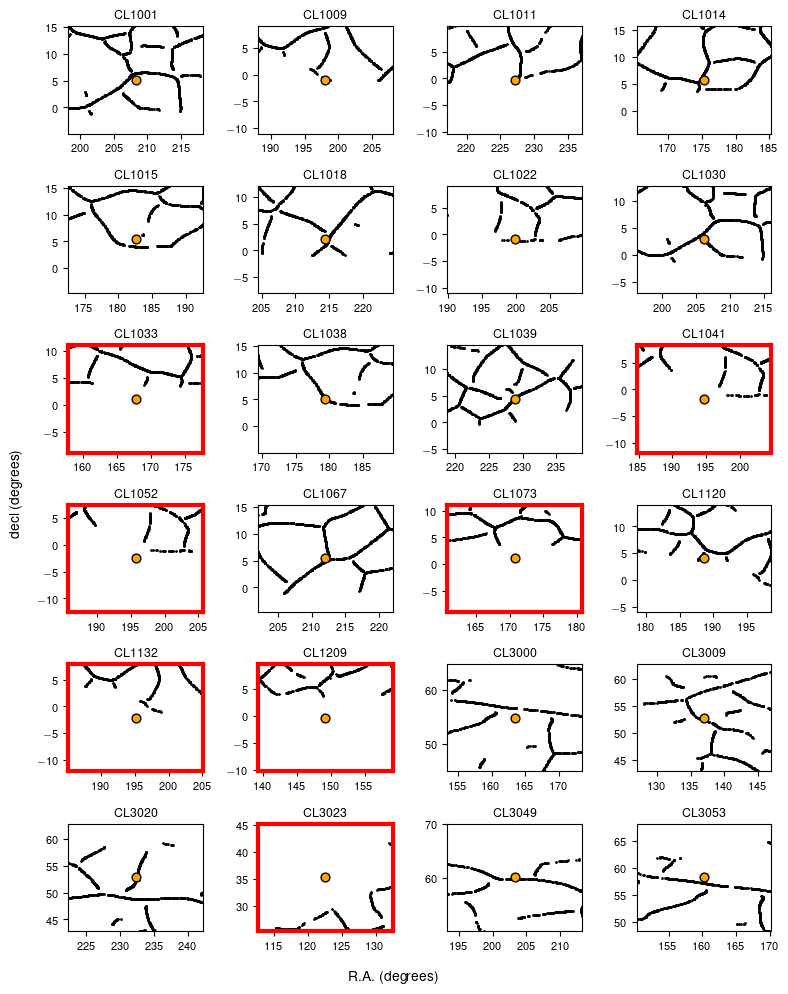

In [38]:
# IDs that should get a thick border
to_drop_restricted = [
    'CL1020','CL1047','CL2007','CL2010','CL2015','CL2045','CL2081',
    'CL3013','CL3030','CL3046','CL1033','CL1041','CL1052','CL1073',
    'CL1132','CL1209','CL3023'
]

mask = ~data_XUCS_all['filtered_Mpc_Vals'].isna()

nplots = mask.sum()
nrows = int(np.ceil(nplots / 2))

fig, axs = plt.subplots(6, 4, figsize=(8, 10))
axs = axs.flatten()

ax_idx = 0  # index for used axes

fig.supxlabel('R.A. (degrees)', fontsize=10)
fig.supylabel('decl (degrees)', fontsize=10)

for i in range(len(data_XUCS_all)):
    if not mask.iloc[i]:
        continue

    ax = axs[ax_idx]

    x = data_XUCS_all.loc[i, 'RAdeg']
    y = data_XUCS_all.loc[i, 'DEdeg']
    cid = data_XUCS_all.loc[i, 'Id']
    zlow = data_XUCS_all.loc[i, 'zLow']

    ax.set_title(cid, fontsize = 9) #15


    # Cluster point
    ax.scatter(x, y, s=40, color='orange', edgecolor='k', zorder=3)

    # Filament slice
    sel = (data_block1['zLow'] >= zlow) & (data_block1['zLow'] < zlow + 0.005)
    ax.scatter(
        data_block1.loc[sel, 'RAdeg'],
        data_block1.loc[sel, 'DEdeg'],
        color='black',
        s=1,
        zorder=1
    )

    ax.set_xlim(x - 10, x + 10)
    ax.set_ylim(y - 10, y + 10)

    # Thick border for restricted IDs
    if cid in to_drop_restricted:
        for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_edgecolor('red')

    ax_idx += 1

# Remove unused axes
'''
for j in range(ax_idx, len(axs)):
    fig.delaxes(axs[j])
'''
for j in range(i + 1, len(axs)):
    axs[j].axis('off')
'''
xlabel_size = plt.gca().xaxis.label.get_fontsize()
ylabel_size = plt.gca().yaxis.label.get_fontsize()
print(xlabel_size)
print(ylabel_size)
'''

plt.tight_layout()
plt.savefig('closeups_CD.pdf', dpi=300, bbox_inches='tight',format='pdf')
plt.show()


Monte-Carlo Scheme: determining percentage of overlap with varying errors over a gaussian distrabution

[43.44871711337256, 42.936623203954944, 42.329825357068884, 42.917517522256155, 43.43580871359446, 42.63174542966279, 42.28343539930511, 42.337818232899956, 43.1042377656827, 43.05285112710926, 42.8939081663594, 43.33097222447604, 42.78555944238348, 42.3699372607951, 41.92892187538856, 42.79902923830924, 42.70204155214091, 42.97890373784711, 42.625350887826855, 43.08798872643812, 42.71132153959631]


NameError: name 'list1' is not defined

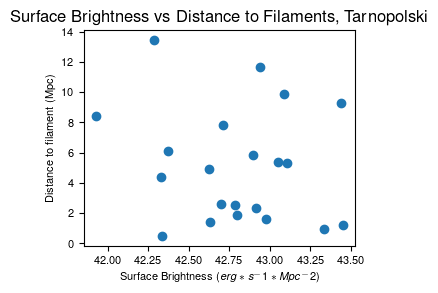

In [31]:
#Plotting surface brightness vs distance to MT for 21 points varying the distrabution
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

xDat = data_XUCS.loc[mask,'SB_Tarnopolski']
errDat = data_XUCS.loc[mask, 'SB err']

gauss_x = []
for i in range(len(xDat)):
    gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
print(gauss_x)

yDat = data_XUCS.loc[mask,'min_distance_to_filament_Haversin_MT (Mpc)']

plt.figure()
plt.title('Surface Brightness vs Distance to Filaments, Tarnopolski')
plt.scatter(gauss_x, yDat)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('Surface Brightness $(erg * s^-1 * Mpc^-2)$')


lowSB = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
medSB = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
highSB = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]

if (len(list1) > 1) & (len(list2) > 1) & (len(list3)>1):
    color_count = 0
    plot_errors(lowSB, 41.9, 42.55)
    
    color_count = 1
    plot_errors(medSB, 42.55, 43.35)
    
    color_count = 2
    plot_errors(highSB, 43.35, 44)

#add vertical lines at 42.55 and 43.35
plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
plt.ylim(0,14)
plt.show()
print(highSB)
errors = [lowSB,medSB,highSB]
print(has_overlap(errors))
plt.savefig('')

In [52]:
#Monte carlo scheme, MT points vary with a gaussian distrabution.
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

xDat = data_XUCS.loc[mask,'SB_Tarnopolski']
print(len(xDat))
errDat = data_XUCS.loc[mask, 'SB err']

countOverlap = 0
runs = 1000

for i in range(runs):
    gauss_x = []
    for i in range(len(xDat)):
        gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
    
    yDat = data_XUCS.loc[mask,'min_distance_to_filament_Haversin_MT (Mpc)']
    
    
    list1 = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
    list2 = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
    list3 = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]
    
    errors = [list1,list2,list3]
    
    if has_overlap(errors):
        countOverlap += 1
print(f'{(countOverlap/runs)*100}% of the time, there are no overlaps, 1 overlap, or 2 overlaps')
print(f'{100-(countOverlap/runs)*100}% of the time, there are 3 overlaps')

21
6.4% of the time, there are no overlaps, 1 overlap, or 2 overlaps
93.6% of the time, there are 3 overlaps


/var/folders/k6/69_wp5355m52d33wn4k48m5h0000gn/T/ipykernel_19934/1280982410.py:20: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(ndlist[i])
/Users/diyalansberg/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,


In [40]:
#Monte carlo scheme, MT points vary with a gaussian distrabution. (copy)
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

xDat = data_XUCS.loc[mask,'SB_Tarnopolski']
print(len(xDat))
errDat = data_XUCS.loc[mask, 'SB err']

countOverlap = 0
runs = 10000

#for i in range(runs):
j = 0
while(j<runs):
    gauss_x = []
    for i in range(len(xDat)):
        gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
    
    yDat = data_XUCS.loc[mask,'min_distance_to_filament_Haversin_MT (Mpc)']
    
    
    list1 = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
    list2 = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
    list3 = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]
    
    errors = [list1,list2,list3]
    if (len(list1) > 1) & (len(list2) > 1) & (len(list3)>1):
        j += 1
        if has_overlap(errors):
            countOverlap += 1
print(f'{(countOverlap/runs)*100}% of the time, there are no overlaps, 1 overlap, or 2 overlaps')
print(f'{100-(countOverlap/runs)*100}% of the time, there are 3 overlaps')

21
10000
5.83% of the time, there are no overlaps, 1 overlap, or 2 overlaps
94.17% of the time, there are 3 overlaps


In [ ]:
#Plotting surface brightness vs distance to Zarattini for 29 points varying the distrabution
xDat = data_XUCS['SB_Tarnopolski']
errDat = data_XUCS['SB err']

countOverlap = 0
runs = 1000

gauss_x = []
for i in range(len(xDat)):
    gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
    
yDat = data_XUCS['Haversin_Dist_Zar (Mpc)']
plt.figure()
plt.title('Surface Brightness vs Distance to Filaments, Zarattini')
plt.scatter(gauss_x, yDat)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('Surface Brightness (erg * s^-1 * Mpc^-2)')


lowSB = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
medSB = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
highSB = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

#add vertical lines at 42.55 and 43.35
plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
plt.ylim(0,14)
plt.show()
print(highSB)
errors = [lowSB,medSB,highSB]
print(has_overlap(errors))

In [ ]:
#Plotting surface brightness vs distance to Zarattini for 29 points varying the distrabution in the y direction (incomplete)
xDat = data_XUCS['SB_Tarnopolski']
errDat = data_XUCS['SB err']

countOverlap = 0
runs = 1000

gauss_x = []
for i in range(len(xDat)):
    gauss_x.append(random.random()*14)
    
yDat = data_XUCS['Haversin_Dist_Zar (Mpc)']
plt.figure()
plt.title('Surface Brightness vs Distance to Filaments, Zarattini')
plt.scatter(gauss_x, yDat)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('Surface Brightness (erg * s^-1 * Mpc^-2)')


lowSB = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
medSB = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
highSB = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

#add vertical lines at 42.55 and 43.35
plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
plt.ylim(0,14)
plt.show()
print(highSB)
errors = [lowSB,medSB,highSB]
print(has_overlap(errors))

In [47]:
#Monte carlo scheme, Zarr points vary with a gaussian distrabution (29).

xDat = data_XUCS['SB_Tarnopolski']
errDat = data_XUCS['SB err']

countOverlap = 0
countOverlap1 = 0
runs = 10000

j = 0
while(j<runs):
    gauss_x = []
    for i in range(len(xDat)):
        gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
    
    yDat = data_XUCS['Haversin_Dist_Zar (Mpc)']
    
    
    list1 = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
    list2 = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
    list3 = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]
    
    errors = [list1,list2,list3]

    if (len(list1) > 1) & (len(list2) > 1) & (len(list3)>1):
        j += 1
        if has_overlap(errors):
            countOverlap += 1
    #if has_overlap_edited(errors):
        #countOverlap1 += 1
print(f'{(countOverlap/runs)*100}% of the time, there are no overlaps, 1 overlap, or 2 overlaps')
print(f'{100 - (countOverlap/runs)*100}% of the time, there are 2 overlaps and a decreasing pattern')



91.69% of the time, there are no overlaps, 1 overlap, or 2 overlaps
8.310000000000002% of the time, there are 2 overlaps and a decreasing pattern


In [ ]:
#Plotting surface brightness vs distance to CD for 24 points varying the distrabution

mask = ~data_XUCS_all['filtered_Mpc_Vals'].isna()

xDat = data_XUCS_all.loc[mask,'SB_Carron_Duque']
errDat = data_XUCS_all.loc[mask, 'SB err']

gauss_x = []
for i in range(len(xDat)):
    gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
print(gauss_x)

yDat = data_XUCS_all.loc[mask,'filtered_Mpc_Vals']

plt.figure()
plt.title('Surface Brightness vs Distance to Filaments, Carron Duque')
plt.scatter(gauss_x, yDat)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('Surface Brightness (erg * s^-1 * Mpc^-2)')


lowSB = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
medSB = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
highSB = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

#add vertical lines at 42.55 and 43.35
plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
#plt.ylim(0,)
plt.show()
print(highSB)
errors = [lowSB,medSB,highSB]
print(has_overlap(errors))

In [ ]:
#Plotting surface brightness vs distance to CD for 17 points varying the distrabution

mask = ~data_XUCS_all['restricted_fil_Mpc_Vals'].isna()

xDat = data_XUCS_all.loc[mask,'SB_Carron_Duque']
errDat = data_XUCS_all.loc[mask, 'SB err']

gauss_x = []
for i in range(len(xDat)):
    gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
print(gauss_x)

yDat = data_XUCS_all.loc[mask,'restricted_fil_Mpc_Vals']

plt.figure()
plt.title('Surface Brightness vs Distance to Filaments, Carron Duque')
plt.scatter(gauss_x, yDat)
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('Surface Brightness (erg * s^-1 * Mpc^-2)')


lowSB = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
medSB = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
highSB = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]

color_count = 0
plot_errors(lowSB, 41.9, 42.55)

color_count = 1
plot_errors(medSB, 42.55, 43.35)

color_count = 2
plot_errors(highSB, 43.35, 44)

#add vertical lines at 42.55 and 43.35
plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
#plt.ylim(0,)
plt.show()
print(highSB)
errors = [lowSB,medSB,highSB]
print(has_overlap(errors))

In [29]:
#Monte carlo scheme, CD points vary with a gaussian distrabution. (24)
mask = ~data_XUCS_all['filtered_Mpc_Vals'].isna()

xDat = data_XUCS_all.loc[mask,'SB_Carron_Duque']
errDat = data_XUCS_all.loc[mask, 'SB err']

countOverlap = 0
runs = 10000

j = 0
while(j<runs):
    gauss_x = []
    for i in range(len(xDat)):
        gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
    
    yDat = data_XUCS_all.loc[mask,'filtered_Mpc_Vals']
    
    
    list1 = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
    list2 = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
    list3 = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]
    
    errors = [list1,list2,list3]

    if (len(list1) > 1) & (len(list2) > 1) & (len(list3)>1):
        j += 1
        if has_overlap(errors):
            countOverlap += 1
print(f'{(countOverlap/runs)*100}% of the time, there are no overlaps, 1 overlap, or 2 overlaps')
print(f'{100-(countOverlap/runs)*100}% of the time, there are 3 overlaps')

1.79% of the time, there are no overlaps, 1 overlap, or 2 overlaps
98.21% of the time, there are 3 overlaps


In [46]:
#Monte carlo scheme, CD points vary with a gaussian distrabution. (17)
mask = ~data_XUCS_all['restricted_fil_Mpc_Vals'].isna()

xDat = data_XUCS_all.loc[mask,'SB_Carron_Duque']
errDat = data_XUCS_all.loc[mask, 'SB err']

countOverlap = 0
runs = 1000

j = 0
while(j<runs):
    gauss_x = []
    for i in range(len(xDat)):
        gauss_x.append(random.gauss(xDat.iloc[i], errDat.iloc[i]))
    
    yDat = data_XUCS_all.loc[mask,'restricted_fil_Mpc_Vals']
    
    
    list1 = [y for x, y in zip(gauss_x, yDat) if 41.9 <= x <= 42.55]
    list2 = [y for x, y in zip(gauss_x, yDat) if 42.55 < x <= 43.35]
    list3 = [y for x, y in zip(gauss_x, yDat) if 43.35 < x <= 44.0]
    
    errors = [list1,list2,list3]

    if (len(list1) > 1) & (len(list2) > 1) & (len(list3)>1):
        j += 1
        if has_overlap(errors):
            countOverlap += 1
print(countOverlap)
print(f'{(countOverlap/runs)*100}% of the time, there are no overlaps, 1 overlap, or 2 overlaps')
print(f'{100-(countOverlap/runs)*100}% of the time, there are 3 overlaps')

934
93.4% of the time, there are no overlaps, 1 overlap, or 2 overlaps
6.599999999999994% of the time, there are 3 overlaps


In [ ]:
#Test for CD paper, 24 points
mask = ~data_XUCS_all['filtered_Mpc_Vals'].isna()
a = data_XUCS_all.loc[mask & (data_XUCS_all.loc[mask,'SB_Carron_Duque'] >= 41.9) & (data_XUCS_all.loc[mask,'SB_Carron_Duque'] <= 42.55), 'filtered_Mpc_Vals']
b = data_XUCS_all.loc[mask & (data_XUCS_all.loc[mask,'SB_Carron_Duque'] >= 42.55) & (data_XUCS_all.loc[mask,'SB_Carron_Duque'] <= 43.35), 'filtered_Mpc_Vals']
c = data_XUCS_all.loc[mask & (data_XUCS_all.loc[mask,'SB_Carron_Duque'] >= 43.35) & (data_XUCS_all.loc[mask,'SB_Carron_Duque'] <= 44.00), 'filtered_Mpc_Vals']
ndlist = [a,b,c]

print(f'Does the CD paper graph have any pattern (not 3 overlaps)? {has_overlap(ndlist)}')

In [184]:
data_XUCS_all

,Id,RAdeg,DEdeg,z,logM500caustic,errlogM500caustic,N,logM500veldisp,errlogM500veldisp,n,...,logLXce,errlogLXce,zLow,block1_Euclid (degrees),block1_Haversin (degrees),block1_Haversin (Mpc),SB_Carron_Duque,SB err,filtered_Mpc_Vals,restricted_fil_Mpc_Vals
0,CL1001,208.256,5.134,0.079,14.30,0.11,171,14.57,0.09,124,...,43.79,0.01,0.075,1.069493,1.066410,5.631853,43.412787,0.074012,5.631853,5.631853
1,CL1009,198.057,-0.974,0.085,14.00,0.26,236,14.28,0.12,56,...,43.24,0.02,0.085,0.295084,0.295083,1.739156,43.064481,0.174483,1.739156,1.739156
2,CL1011,227.107,-0.266,0.091,14.23,0.17,48,14.46,0.14,42,...,42.77,0.07,0.090,0.120239,0.120238,0.744838,42.442852,0.133208,0.744838,0.744838
3,CL1014,175.299,5.735,0.098,14.40,0.09,120,14.40,0.16,51,...,43.31,0.04,0.095,0.540302,0.538040,3.493001,42.871517,0.072111,3.493001,3.493001
4,CL1015,182.570,5.386,0.077,13.85,0.19,79,14.14,0.15,37,...,43.55,0.01,0.075,1.250278,1.246329,6.582029,43.472224,0.127061,6.582029,6.582029
5,CL1018,214.398,2.053,0.054,13.68,0.24,123,14.27,0.10,79,...,42.73,0.05,0.050,0.514827,0.514497,1.895414,42.759156,0.167631,1.895414,1.895414
6,CL1020,176.028,5.798,0.103,13.94,0.35,29,14.61,0.14,43,...,43.61,0.03,0.100,0.238535,0.237376,1.610829,43.479618,0.235254,NaN,NaN
7,CL1022,199.821,-0.919,0.083,13.86,0.12,87,13.56,0.16,36,...,42.55,0.10,0.080,0.222622,0.222619,1.244283,42.467249,0.128062,1.244283,1.244283
8,CL1030,206.165,2.860,0.078,14.16,0.09,86,14.12,0.21,41,...,42.54,0.09,0.075,0.300263,0.300183,1.585304,42.255838,0.108167,1.585304,1.585304
9,CL1033,167.747,1.128,0.097,13.83,0.12,77,13.79,0.21,20,...,43.05,0.05,0.095,2.916382,2.915871,18.930093,42.991231,0.094340,18.930093,NaN


In [32]:
#Function for plotting x-error in graph below (all catalogs)
'''
errs --> a list of errors that correspond to that section of data.
ex. err_low_SB = data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'SB err']

dist --> the distance points used (must correspond with indicies of errs). needed for y-coordinates in plt.scatter(x,y)
ex. lowSB = data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'min_distance_to_filament_Haversin_MT (Mpc)']

Xval_plotted --> where to plot the error bars. should be at the average of that box. Note! this is not Avg (defined below)
because that is the average of the y values (distances).
ex. lowSB_x_ave = np.nanmean(data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'SB_Tarnopolski'])

'''
def plot_errors_x(errs,dist,Xval_plotted):
    #counts the amount of non-nan values in the list errs
    count = np.count_nonzero(~np.isnan(errs))
    #calculates average for errs
    Avg = np.nanmean(dist)
    
    #sums the squares of all errors
    Errs = 0
    for i in errs:
        Errs += i**2

    #divides the squareroot of the sums of squares by the count
    Err = np.sqrt(Errs)/count
    colors = ['red','orange','green','purple']

    plt.plot(Xval_plotted,Avg,c=colors[color_count])
    plt.errorbar(Xval_plotted,Avg,xerr=Err,fmt='o-', capsize=5, color=colors[color_count], linewidth=1)


In [187]:
#Plotting the averages of all three catalogs with their distances (Very messy, use one in cell below)

#MT
mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

xDat = data_XUCS.loc[mask,'SB_Tarnopolski']
yDat = data_XUCS.loc[mask,'min_distance_to_filament_Haversin_MT (Mpc)']

plt.figure()
plt.title('Comparing distance averages between the three catalogs')
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('Surface Brightness (erg * s^-1 * Mpc^-2)')

lowSB = data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'min_distance_to_filament_Haversin_MT (Mpc)']
lowSB_x_ave = np.nanmean(data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'SB_Tarnopolski'])
medSB = data_XUCS.loc[mask & (42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'min_distance_to_filament_Haversin_MT (Mpc)']
medSB_x_ave = np.nanmean(data_XUCS.loc[mask & (42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'SB_Tarnopolski'])
highSB = data_XUCS.loc[mask & (43.35 < data_XUCS['SB_Tarnopolski']), 'min_distance_to_filament_Haversin_MT (Mpc)']
highSB_x_ave = np.nanmean(data_XUCS.loc[mask & (43.35 < data_XUCS['SB_Tarnopolski']), 'SB_Tarnopolski'])

err_low_SB = data_XUCS.loc[mask & (data_XUCS['SB_Tarnopolski'] <= 42.55), 'SB err']
err_med_SB = data_XUCS.loc[mask & (42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'SB err']
err_high_SB = data_XUCS.loc[mask & (43.35 < data_XUCS['SB_Tarnopolski']), 'SB err']

#if placed evenly within box: 42.0625
color_count = 0
plot_errors_specific(lowSB,lowSB_x_ave)
plot_errors_x(err_low_SB,lowSB,lowSB_x_ave)

color_count = 0
plot_errors_specific(medSB,medSB_x_ave)
plot_errors_x(err_med_SB,medSB,medSB_x_ave)

color_count = 0
plot_errors_specific(highSB,highSB_x_ave)
plot_errors_x(err_med_SB,highSB,highSB_x_ave)


#Zar

xDat = data_XUCS['SB_Tarnopolski']
yDat = data_XUCS['Haversin_Dist_Zar (Mpc)']

lowSB = data_XUCS.loc[(data_XUCS['SB_Tarnopolski'] <= 42.55), 'Haversin_Dist_Zar (Mpc)']
lowSB_x = data_XUCS.loc[(data_XUCS['SB_Tarnopolski'] <= 42.55), 'SB_Tarnopolski']
lowSB_x_ave = np.nanmean(lowSB_x)

medSB = data_XUCS.loc[(42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'Haversin_Dist_Zar (Mpc)']
medSB_x_ave = np.nanmean(data_XUCS.loc[(42.55 < data_XUCS['SB_Tarnopolski']) & (data_XUCS['SB_Tarnopolski']<= 43.35), 'SB_Tarnopolski'])
highSB = data_XUCS.loc[(43.35 < data_XUCS['SB_Tarnopolski']), 'Haversin_Dist_Zar (Mpc)']
highSB_x_ave = np.nanmean(data_XUCS.loc[(43.35 < data_XUCS['SB_Tarnopolski']), 'SB_Tarnopolski'])

color_count = 1
plot_errors_specific(lowSB,lowSB_x_ave)
plot_errors_x(err_low_SB,lowSB,lowSB_x_ave)

color_count = 1
plot_errors_specific(medSB,medSB_x_ave)
plot_errors_x(err_med_SB,medSB,medSB_x_ave)

color_count = 1
plot_errors_specific(highSB,highSB_x_ave)
plot_errors_x(err_med_SB,highSB,highSB_x_ave)

#Carron Duque
lowSB = data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'filtered_Mpc_Vals']
lowSB_x_ave = np.nanmean(data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'SB_Carron_Duque'])
medSB = data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'filtered_Mpc_Vals']
medSB_x_ave = np.nanmean(data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'SB_Carron_Duque'])
highSB = data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'filtered_Mpc_Vals']
highSB_x_ave = np.nanmean(data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'SB_Carron_Duque'])

err_low_SB = data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'SB err']
err_med_SB = data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'SB err']
err_high_SB = data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'SB err']


#if placed evenly within box: 42.3875
color_count = 2
plot_errors_specific(lowSB,lowSB_x_ave)
plot_errors_x(err_low_SB,lowSB,lowSB_x_ave)

#if placed evenly within box: 43.15
color_count = 2
plot_errors_specific(medSB,medSB_x_ave)
plot_errors_x(err_med_SB,medSB,medSB_x_ave)

#if placed evenly within box: 43.8375
color_count = 2
plot_errors_specific(highSB,highSB_x_ave)
plot_errors_x(err_med_SB,highSB,highSB_x_ave)

#Carron Duque (17 points)
lowSB = data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'restricted_fil_Mpc_Vals']
lowSB_x_ave = np.nanmean(data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'SB_Carron_Duque'])
medSB = data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'restricted_fil_Mpc_Vals']
medSB_x_ave = np.nanmean(data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'SB_Carron_Duque'])
highSB = data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'restricted_fil_Mpc_Vals']
highSB_x_ave = np.nanmean(data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'SB_Carron_Duque'])

err_low_SB = data_XUCS_all.loc[(data_XUCS_all['SB_Carron_Duque'] <= 42.55), 'SB err']
err_med_SB = data_XUCS_all.loc[(42.55 < data_XUCS_all['SB_Carron_Duque']) & (data_XUCS_all['SB_Carron_Duque']<= 43.35), 'SB err']
err_high_SB = data_XUCS_all.loc[43.35 < data_XUCS_all['SB_Carron_Duque'], 'SB err']

#if placed evenly within box: 42.3875
color_count = 3
plot_errors_specific(lowSB,lowSB_x_ave)
plot_errors_x(err_low_SB,lowSB,lowSB_x_ave)

#if placed evenly within box: 43.15
color_count = 3
plot_errors_specific(medSB,medSB_x_ave)
plot_errors_x(err_med_SB,medSB,medSB_x_ave)

#if placed evenly within box: 43.8375
color_count = 3
plot_errors_specific(highSB,highSB_x_ave)
plot_errors_x(err_med_SB,highSB,highSB_x_ave)

#add vertical lines at 42.55 and 43.35
plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9,44)
legend_elements = [
    Line2D([0], [0], marker='o', color='red', label='Tarnopolski'),
    Line2D([0], [0], marker='o', color='orange', label='Zarattini'),
    Line2D([0], [0], marker='o', color='green', label='Carron Duque (24)')
    Line2D([0], [0], marker='o', color='purple', label='Carron Duque (17)')
]
plt.legend(handles=legend_elements)
plt.savefig('comparison_averages',format='pdf')
#plt.ylim(0,14)


SyntaxError: invalid syntax (41202086.py, line 128)

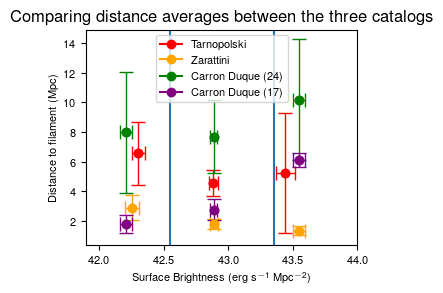

In [33]:
# --- Constants ---
SB_BINS = [(None, 42.55), (42.55, 43.35), (43.35, None)]

# --- Helper functions ---
def sb_mask(df, sb_col, low=None, high=None, extra_mask=None):
    mask = pd.Series(True, index=df.index)
    if low is not None:
        mask &= df[sb_col] > low
    if high is not None:
        mask &= df[sb_col] <= high
    if extra_mask is not None:
        mask &= extra_mask
    return mask


def get_sb_stats(df, sb_col, dist_col, err_col, mask):
    dist = df.loc[mask, dist_col]
    sb_avg = np.nanmean(df.loc[mask, sb_col])
    err = df.loc[mask, err_col]
    return dist, sb_avg, err


def plot_sb_bin(df, sb_col, dist_col, err_col, color_idx, extra_mask=None):
    global color_count
    color_count = color_idx

    for low, high in SB_BINS:
        mask = sb_mask(df, sb_col, low, high, extra_mask)
        dist, sb_avg, err = get_sb_stats(df, sb_col, dist_col, err_col, mask)

        plot_errors_specific(dist, sb_avg)
        plot_errors_x(err, dist, sb_avg)


# --- Figure setup ---
plt.figure()
plt.title('Comparing distance averages between the three catalogs')
plt.ylabel('Distance to filament (Mpc)')
plt.xlabel('Surface Brightness (erg s$^{-1}$ Mpc$^{-2}$)')


# =====================
# Tarnopolski (MT)
# =====================
mt_mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

plot_sb_bin(
    df=data_XUCS,
    sb_col='SB_Tarnopolski',
    dist_col='min_distance_to_filament_Haversin_MT (Mpc)',
    err_col='SB err',
    color_idx=0,
    extra_mask=mt_mask
)


# =====================
# Zarattini
# =====================
plot_sb_bin(
    df=data_XUCS,
    sb_col='SB_Tarnopolski',
    dist_col='Haversin_Dist_Zar (Mpc)',
    err_col='SB err',
    color_idx=1
)


# =====================
# Carron Duque (24)
# =====================
plot_sb_bin(
    df=data_XUCS_all,
    sb_col='SB_Carron_Duque',
    dist_col='filtered_Mpc_Vals',
    err_col='SB err',
    color_idx=2
)


# =====================
# Carron Duque (17)
# =====================
plot_sb_bin(
    df=data_XUCS_all,
    sb_col='SB_Carron_Duque',
    dist_col='restricted_fil_Mpc_Vals',
    err_col='SB err',
    color_idx=3
)


# --- Decorations ---
plt.axvline(x=42.55)
plt.axvline(x=43.35)
plt.xlim(41.9, 44)

legend_elements = [
    Line2D([0], [0], marker='o', color='red', label='Tarnopolski'),
    Line2D([0], [0], marker='o', color='orange', label='Zarattini'),
    Line2D([0], [0], marker='o', color='green', label='Carron Duque (24)'),
    Line2D([0], [0], marker='o', color='purple', label='Carron Duque (17)')
]

plt.legend(handles=legend_elements)
plt.savefig('comparison_averages.pdf')

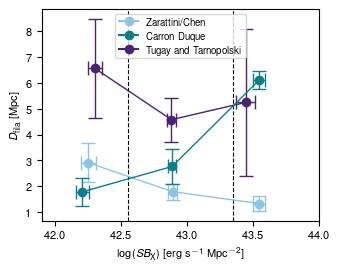

In [34]:
# --- Constants ---
SB_BINS = [(None, 42.55), (42.55, 43.35), (43.35, None)]
colors = ['#4a2377','#8cc5e3','#f55f74','#0d7d87']

# --- Helper functions ---
def sb_mask(df, sb_col, low=None, high=None, extra_mask=None):
    mask = pd.Series(True, index=df.index)
    if low is not None:
        mask &= df[sb_col] > low
    if high is not None:
        mask &= df[sb_col] <= high
    if extra_mask is not None:
        mask &= extra_mask
    return mask


def get_sb_stats(df, sb_col, dist_col, err_col, mask):
    sb = df.loc[mask, sb_col]
    dist = df.loc[mask, dist_col]
    sb_err = df.loc[mask, err_col]

    x = np.nanmean(sb)
    y = np.nanmean(dist)

    xerr = np.sqrt(np.nansum(sb_err**2)) / np.count_nonzero(~np.isnan(sb_err))
    yerr = np.nanstd(dist) / np.sqrt(np.count_nonzero(~np.isnan(dist)))

    return x, y, xerr, yerr


def plot_sb_bin(df, sb_col, dist_col, err_col, color_idx, extra_mask=None):
    #colors = ['red','orange','green','purple']

    xs, ys, xerrs, yerrs = [], [], [], []

    for low, high in SB_BINS:
        mask = sb_mask(df, sb_col, low, high, extra_mask)
        x, y, xerr, yerr = get_sb_stats(df, sb_col, dist_col, err_col, mask)

        xs.append(x)
        ys.append(y)
        xerrs.append(xerr)
        yerrs.append(yerr)

    plt.errorbar(
        xs, ys,
        xerr=xerrs,
        yerr=yerrs,
        fmt='o-',
        capsize=5,
        linewidth=1,
        color=colors[color_idx]
    )



# --- Figure setup ---
plt.figure()
plt.xlabel(r'$\log(SB_{\mathrm{X}}) \ [\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{Mpc}^{-2}]$')
plt.ylabel(r'$D_{\mathrm{fila}} \ [\mathrm{Mpc}]$')



# =====================
# Tarnopolski (MT)
# =====================
mt_mask = ~data_XUCS['min_distance_to_filament_Euclid_MT (degrees)'].isna()

plot_sb_bin(
    df=data_XUCS,
    sb_col='SB_Tarnopolski',
    dist_col='min_distance_to_filament_Haversin_MT (Mpc)',
    err_col='SB err',
    color_idx=0,
    extra_mask=mt_mask
)


# =====================
# Zarattini
# =====================
plot_sb_bin(
    df=data_XUCS,
    sb_col='SB_Tarnopolski',
    dist_col='Haversin_Dist_Zar (Mpc)',
    err_col='SB err',
    color_idx=1
)


# =====================
# Carron Duque (17)
# =====================
plot_sb_bin(
    df=data_XUCS_all,
    sb_col='SB_Carron_Duque',
    dist_col='restricted_fil_Mpc_Vals',
    err_col='SB err',
    color_idx=3
)


# --- Decorations ---
plt.axvline(x=42.55,linestyle = '--',linewidth=0.8,color='black')
plt.axvline(x=43.35,linestyle = '--',linewidth=0.8,color='black')
plt.xlim(41.9, 44)

legend_elements = [
    Line2D([0], [0], marker='o', color=colors[1], label='Zarattini/Chen'),
    Line2D([0], [0], marker='o', color=colors[3], label='Carron Duque'),
    Line2D([0], [0], marker='o', color=colors[0], label='Tugay and Tarnopolski')
]

plt.legend(handles=legend_elements,fontsize=7,loc=9)
plt.tight_layout()
plt.savefig('comparison_averages_CD17.pdf')

In [ ]:
#test for above
add = (42.55-41.9)/4
print(41.9+add)
print(41.9+2*add)
print(41.9+3*add)

In [ ]:
#test for above
add = (43.35-42.55)/4
print(42.55+add)
print(42.55+2*add)
print(42.55+3*add)

In [ ]:
#test for above
add = (44-43.35)/4
print(43.35+add)
print(43.35+2*add)
print(43.35+3*add)

In [ ]:
data_XUCS_all.head()

In [ ]:
#printing data table with all CL values and their distances according to each catalog.
# Create IDs
ids = [f"CL{i}" for i in range(1, 35)]

# Instantiate DataFrame
distances = pd.DataFrame({
    "ID": data_XUCS_all['Id'],
    "Chen": [None] * 34,
    "Tugay": [None] * 34,
    "Carron-Duque": data_XUCS_all['filtered_Mpc_Vals']
})

distances

In [ ]:
distances = distances.merge(
    data_XUCS[
        ["Id",
         "Haversin_Dist_Zar (Mpc)",
         "min_distance_to_filament_Haversin_MT (Mpc)"]
    ],
    left_on="ID",
    right_on="Id",
    how="left"
)

distances["Chen"] = distances["Haversin_Dist_Zar (Mpc)"]
distances["Tugay"] = distances["min_distance_to_filament_Haversin_MT (Mpc)"]

distances = distances.drop(columns=[
    "Id",
    "Haversin_Dist_Zar (Mpc)",
    "min_distance_to_filament_Haversin_MT (Mpc)"
])
distances[["Chen", "Tugay", "Carron-Duque"]] = distances[["Chen", "Tugay", "Carron-Duque"]].round(3)

In [ ]:
distances.to_csv('distances.csv')

In [ ]:
from scipy import constants
def f(c=constants.c,pi=constants.pi,ep=constants.epsilon_0,a0=5*10**(-11),e=constants.eV):
    print((-12*c**3*pi**2*ep**2*a0**3)/(e**4))
f()